# PatrolIQ — Smart Safety Analytics Platform
### GUVI | HCL Capstone Project
**Domain:** Public Safety & Urban Analytics

**Goal:** Analyze 500,000 Chicago crime records using unsupervised ML to identify crime hotspots and optimize police patrol resource allocation.

---
**Pipeline:**
```
Data (7.8M) -> Sample 500K -> Preprocessing -> Feature Engineering
-> EDA -> Clustering (K-Means, DBSCAN, Hierarchical)
-> Dimensionality Reduction (PCA + t-SNE) -> MLflow -> Deploy
```

## Phase 1: Import Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import mlflow
import mlflow.sklearn
import os

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

print('=' * 60)
print('ALL LIBRARIES IMPORTED SUCCESSFULLY')
print('=' * 60)
print('  pandas  :', pd.__version__)
print('  numpy   :', np.__version__)
print('  mlflow  :', mlflow.__version__)
print('  sklearn : OK')
print('=' * 60)

ALL LIBRARIES IMPORTED SUCCESSFULLY
  pandas  : 2.3.3
  numpy   : 2.4.4
  mlflow  : 3.11.1
  sklearn : OK


## Phase 2: Data Acquisition & Loading

**Why?** The Chicago Crime Dataset has 7.8 million records. We load and sample the 500,000 most recent so our model reflects current patterns, not decade-old ones.

Dataset link: https://data.cityofchicago.org/Public-Safety/Crimes-2001-to-Present/ijzp-q8t2

In [35]:
# STEP 2.1 — Load the full CSV
print('=' * 60)
print('LOADING CHICAGO CRIME DATASET...')
print('=' * 60)

df_full = pd.read_csv('patrol.csv', low_memory=False)

print('Dataset loaded!')
print('  Total Records :', f'{len(df_full):,}')
print('  Total Columns :', df_full.shape[1])
print('  Memory        :', f'{df_full.memory_usage(deep=True).sum()/1e9:.2f} GB')
print()
print('Column names:')
for i, c in enumerate(df_full.columns, 1):
    print(f'  {i:2}. {c}')

LOADING CHICAGO CRIME DATASET...
Dataset loaded!
  Total Records : 500,000
  Total Columns : 23
  Memory        : 0.36 GB

Column names:
   1. Unnamed: 0
   2. ID
   3. Case Number
   4. Date
   5. Block
   6. IUCR
   7. Primary Type
   8. Description
   9. Location Description
  10. Arrest
  11. Domestic
  12. Beat
  13. District
  14. Ward
  15. Community Area
  16. FBI Code
  17. X Coordinate
  18. Y Coordinate
  19. Year
  20. Updated On
  21. Latitude
  22. Longitude
  23. Location


In [36]:
# STEP 2.2 — Preview BEFORE any processing
print('=' * 60)
print('BEFORE PROCESSING — RAW DATA PREVIEW')
print('=' * 60)
print()
print('First 5 rows:')
print(df_full.head().to_string())
print()
print('Data types:')
print(df_full.dtypes.to_string())
print()
print('Basic statistics:')
print(df_full.describe(include='all').T[['count','unique','top','mean','std']].fillna('---').to_string())

BEFORE PROCESSING — RAW DATA PREVIEW

First 5 rows:
   Unnamed: 0        ID Case Number                    Date                 Block  IUCR     Primary Type             Description       Location Description  Arrest  Domestic  Beat  District    Ward  Community Area FBI Code  X Coordinate  Y Coordinate  Year              Updated On  Latitude  Longitude                       Location
0     3003201   9626531    HX277213  05/26/2014 02:40:00 PM  060XX S PARKSIDE AVE  1320  CRIMINAL DAMAGE              TO VEHICLE                      ALLEY   False     False   812    8.0000 13.0000         64.0000       14  1139765.0000  1863916.0000  2014  02/10/2018 03:50:01 PM   41.7827   -87.7631  (41.782683116, -87.763130178)
1     4353035   7484588    HS287993  05/03/2010 04:45:00 AM    011XX W WILSON AVE  033A          ROBBERY  ATTEMPT: ARMED-HANDGUN                   SIDEWALK   False     False  2311   19.0000 46.0000          3.0000       03  1167625.0000  1930696.0000  2010  02/10/2018 03:50:01 PM  

In [37]:
# STEP 2.3 — Sample 500,000 most recent records
print('=' * 60)
print('SAMPLING 500,000 MOST RECENT RECORDS')
print('=' * 60)
print()
print('BEFORE sampling :', f'{len(df_full):,}', 'records')

df_full['Date'] = pd.to_datetime(df_full['Date'], format='mixed', errors='coerce')
df_full = df_full.sort_values('Date', ascending=False)
df = df_full.head(500000).reset_index(drop=True)

print('AFTER  sampling :', f'{len(df):,}', 'records')
print()
print('Date range in sample:')
print('  Earliest :', df['Date'].min())
print('  Latest   :', df['Date'].max())
print()
print('First 5 rows of sampled data:')
print(df[['Date','Primary Type','Latitude','Longitude','District','Arrest']].head().to_string())

SAMPLING 500,000 MOST RECENT RECORDS

BEFORE sampling : 500,000 records
AFTER  sampling : 500,000 records

Date range in sample:
  Earliest : 2001-01-01 00:00:00
  Latest   : 2026-05-05 23:20:00

First 5 rows of sampled data:
                 Date                      Primary Type  Latitude  Longitude  District  Arrest
0 2026-05-05 23:20:00  INTERFERENCE WITH PUBLIC OFFICER   41.8816   -87.6278    1.0000    True
1 2026-05-05 23:00:00                          BURGLARY   41.9621   -87.7034   17.0000   False
2 2026-05-05 21:56:00                   CRIMINAL DAMAGE   41.7245   -87.6329    6.0000   False
3 2026-05-05 20:30:00                          BURGLARY   41.9564   -87.6995   17.0000   False
4 2026-05-05 18:00:00                           ASSAULT   41.7853   -87.7229    8.0000   False


## Phase 3: Data Preprocessing & Cleaning

**Why?** Real crime data is messy — missing coordinates, wrong types, duplicates. ML algorithms either crash or produce garbage on dirty data.

**Rule:** Print BEFORE cleaning → fix → print AFTER to confirm every change.

In [38]:
# STEP 3.1 — Check NULL values BEFORE cleaning
print('=' * 60)
print('BEFORE CLEANING — NULL VALUE CHECK')
print('=' * 60)
print()

null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)

null_df = pd.DataFrame({
    'Null Count' : null_counts,
    'Null Pct %' : null_pct,
    'Has Nulls'  : null_counts.apply(lambda x: 'YES' if x > 0 else 'NO')
}).sort_values('Null Count', ascending=False)

print(null_df.to_string())
print()
print('Total missing cells :', f'{df.isnull().sum().sum():,}')
print('Columns with nulls  :', (null_counts > 0).sum())
print('Dataset shape BEFORE:', df.shape)

BEFORE CLEANING — NULL VALUE CHECK

                      Null Count  Null Pct % Has Nulls
Ward                       35891      7.1800       YES
Community Area             35817      7.1600       YES
X Coordinate                5577      1.1200       YES
Location                    5577      1.1200       YES
Y Coordinate                5577      1.1200       YES
Longitude                   5577      1.1200       YES
Latitude                    5577      1.1200       YES
Location Description         914      0.1800       YES
District                       3      0.0000       YES
Block                          0      0.0000        NO
IUCR                           0      0.0000        NO
Case Number                    0      0.0000        NO
ID                             0      0.0000        NO
Unnamed: 0                     0      0.0000        NO
Date                           0      0.0000        NO
Primary Type                   0      0.0000        NO
Description                  

In [39]:
# STEP 3.2 — Handle NULL values
print('=' * 60)
print('CLEANING NULL VALUES...')
print('=' * 60)
print()

rows_before = len(df)
print('Rows BEFORE cleaning :', f'{rows_before:,}')

# Drop rows where Lat/Long is missing — critical for geographic clustering
dropped = df[df['Latitude'].isnull() | df['Longitude'].isnull()].shape[0]
df = df.dropna(subset=['Latitude', 'Longitude'])
print(f'  Dropped {dropped:,} rows with missing Lat/Long')
print('  Reason: Geographic clustering needs coordinates')

# Fill text columns
for col in ['Location Description', 'Block', 'Description']:
    if col in df.columns:
        n = df[col].isnull().sum()
        df[col] = df[col].fillna('UNKNOWN')
        if n > 0:
            print(f'  Filled {n:,} nulls in "{col}" with UNKNOWN')

# Fill numeric admin columns with mode
for col in ['Ward', 'Community Area', 'District', 'Beat']:
    if col in df.columns:
        n = df[col].isnull().sum()
        if n > 0:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f'  Filled {n:,} nulls in "{col}" with mode={mode_val}')

# Remove duplicates
dupes = df.duplicated().sum()
df = df.drop_duplicates()
print(f'  Removed {dupes:,} duplicate rows')

rows_after = len(df)
print()
print('Rows AFTER  cleaning :', f'{rows_after:,}')
print('Rows removed total   :', f'{rows_before - rows_after:,}')
print('Data retained        :', f'{rows_after/rows_before*100:.2f}%')

CLEANING NULL VALUES...

Rows BEFORE cleaning : 500,000
  Dropped 5,577 rows with missing Lat/Long
  Reason: Geographic clustering needs coordinates
  Filled 578 nulls in "Location Description" with UNKNOWN
  Filled 35,389 nulls in "Ward" with mode=28.0
  Filled 35,329 nulls in "Community Area" with mode=25.0
  Filled 3 nulls in "District" with mode=8.0
  Removed 0 duplicate rows

Rows AFTER  cleaning : 494,423
Rows removed total   : 5,577
Data retained        : 98.88%


In [40]:
# STEP 3.3 — Verify NULL values AFTER cleaning
print('=' * 60)
print('AFTER CLEANING — NULL VALUE CHECK')
print('=' * 60)
print()

null_after = df.isnull().sum()
null_pct_after = (null_after / len(df) * 100).round(2)

null_after_df = pd.DataFrame({
    'Null Count' : null_after,
    'Null Pct %' : null_pct_after,
    'Status'     : null_after.apply(lambda x: 'CLEAN' if x == 0 else 'STILL HAS NULLS')
}).sort_values('Null Count', ascending=False)

remaining = null_after_df[null_after_df['Null Count'] > 0]
if len(remaining) == 0:
    print('No null values remaining in critical columns!')
else:
    print('Remaining nulls (non-critical):')
    print(remaining.to_string())

print()
print('Total null values remaining :', null_after.sum())
print('Dataset shape after cleaning:', df.shape)
print()
print('Sample rows after cleaning:')
print(df[['Date','Primary Type','Latitude','Longitude','District','Arrest']].head(8).to_string(index=False))

AFTER CLEANING — NULL VALUE CHECK

No null values remaining in critical columns!

Total null values remaining : 0
Dataset shape after cleaning: (494423, 23)

Sample rows after cleaning:
               Date                     Primary Type  Latitude  Longitude  District  Arrest
2026-05-05 23:20:00 INTERFERENCE WITH PUBLIC OFFICER   41.8816   -87.6278    1.0000    True
2026-05-05 23:00:00                         BURGLARY   41.9621   -87.7034   17.0000   False
2026-05-05 21:56:00                  CRIMINAL DAMAGE   41.7245   -87.6329    6.0000   False
2026-05-05 20:30:00                         BURGLARY   41.9564   -87.6995   17.0000   False
2026-05-05 18:00:00                          ASSAULT   41.7853   -87.7229    8.0000   False
2026-05-05 17:30:00                    OTHER OFFENSE   41.9029   -87.7693   25.0000   False
2026-05-05 17:20:00               DECEPTIVE PRACTICE   41.8877   -87.6171    1.0000   False
2026-05-05 17:00:00                         BURGLARY   41.9495   -87.7680   16

In [41]:
# STEP 3.4 — Fix Data Types
print('=' * 60)
print('FIXING DATA TYPES')
print('=' * 60)
print()
print('BEFORE — data types:')
print(df.dtypes.to_string())

df['Date']     = pd.to_datetime(df['Date'], errors='coerce')
df['Year']     = df['Year'].astype(int)
df['Arrest']   = df['Arrest'].astype(bool)
df['Domestic'] = df['Domestic'].astype(bool)
df['Latitude']       = df['Latitude'].astype(float)
df['Longitude']      = df['Longitude'].astype(float)
df['District']       = pd.to_numeric(df['District'],       errors='coerce')
df['Ward']           = pd.to_numeric(df['Ward'],           errors='coerce')
df['Community Area'] = pd.to_numeric(df['Community Area'], errors='coerce')

print()
print('AFTER — data types:')
print(df.dtypes.to_string())
print()
print('Data types fixed!')

FIXING DATA TYPES

BEFORE — data types:
Unnamed: 0                       int64
ID                               int64
Case Number                     object
Date                    datetime64[ns]
Block                           object
IUCR                            object
Primary Type                    object
Description                     object
Location Description            object
Arrest                            bool
Domestic                          bool
Beat                             int64
District                       float64
Ward                           float64
Community Area                 float64
FBI Code                        object
X Coordinate                   float64
Y Coordinate                   float64
Year                             int64
Updated On                      object
Latitude                       float64
Longitude                      float64
Location                        object

AFTER — data types:
Unnamed: 0                       int64
ID 

## Phase 4: Feature Engineering

**Why?** The raw 22 columns hide the most useful patterns inside datetime strings and text labels. We extract them as numbers so ML algorithms can use them.

- `Date` → Hour, Day, Month, Season, Is_Weekend, Time_of_Day
- `Primary Type` → Crime_Severity_Score (1–10), Crime_Type_Encoded

In [42]:
# STEP 4.1 — BEFORE feature engineering
print('=' * 60)
print('BEFORE FEATURE ENGINEERING')
print('=' * 60)
print()
print('Number of columns :', df.shape[1])
print('Column names      :', list(df.columns))
print()
print('Sample Date column (raw) — no time features exist yet:')
print(df['Date'].head(8).to_string())
print()
print('No Hour / Season / Severity columns exist yet.')

BEFORE FEATURE ENGINEERING

Number of columns : 23
Column names      : ['Unnamed: 0', 'ID', 'Case Number', 'Date', 'Block', 'IUCR', 'Primary Type', 'Description', 'Location Description', 'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Community Area', 'FBI Code', 'X Coordinate', 'Y Coordinate', 'Year', 'Updated On', 'Latitude', 'Longitude', 'Location']

Sample Date column (raw) — no time features exist yet:
0   2026-05-05 23:20:00
1   2026-05-05 23:00:00
2   2026-05-05 21:56:00
3   2026-05-05 20:30:00
4   2026-05-05 18:00:00
5   2026-05-05 17:30:00
6   2026-05-05 17:20:00
7   2026-05-05 17:00:00

No Hour / Season / Severity columns exist yet.


In [43]:
# STEP 4.2 — Create Temporal Features
print('=' * 60)
print('CREATING TEMPORAL FEATURES FROM DATE COLUMN...')
print('=' * 60)
print()
print('BEFORE — only raw Date column:')
print(df['Date'].head(5).to_string())

def get_season(month):
    if month in [12, 1, 2]:   return 'Winter'
    elif month in [3, 4, 5]:  return 'Spring'
    elif month in [6, 7, 8]:  return 'Summer'
    else:                      return 'Fall'

def get_time_of_day(hour):
    if   0 <= hour < 6:   return 'Late Night'
    elif 6 <= hour < 12:  return 'Morning'
    elif 12 <= hour < 18: return 'Afternoon'
    else:                  return 'Evening'

df['Hour']        = df['Date'].dt.hour
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Day_Num']     = df['Date'].dt.dayofweek
df['Month']       = df['Date'].dt.month
df['Is_Weekend']  = df['Date'].dt.dayofweek >= 5
df['Season']      = df['Month'].apply(get_season)
df['Time_of_Day'] = df['Hour'].apply(get_time_of_day)

print()
print('AFTER — new temporal columns created:')
print(f'{"Feature":<20} {"Sample Values"}')
print('-' * 60)
for col in ['Hour','Day_of_Week','Month','Is_Weekend','Season','Time_of_Day']:
    vals = str(df[col].unique()[:4].tolist())
    print(f'  {col:<20} {vals}')
print()
print('Sample rows with temporal features:')
print(df[['Date','Hour','Day_of_Week','Season','Time_of_Day','Is_Weekend']].head(8).to_string(index=False))

CREATING TEMPORAL FEATURES FROM DATE COLUMN...

BEFORE — only raw Date column:
0   2026-05-05 23:20:00
1   2026-05-05 23:00:00
2   2026-05-05 21:56:00
3   2026-05-05 20:30:00
4   2026-05-05 18:00:00

AFTER — new temporal columns created:
Feature              Sample Values
------------------------------------------------------------
  Hour                 [23, 21, 20, 18]
  Day_of_Week          ['Tuesday', 'Monday', 'Sunday', 'Saturday']
  Month                [5, 4, 3, 2]
  Is_Weekend           [False, True]
  Season               ['Spring', 'Winter', 'Fall', 'Summer']
  Time_of_Day          ['Evening', 'Afternoon', 'Morning', 'Late Night']

Sample rows with temporal features:
               Date  Hour Day_of_Week Season Time_of_Day  Is_Weekend
2026-05-05 23:20:00    23     Tuesday Spring     Evening       False
2026-05-05 23:00:00    23     Tuesday Spring     Evening       False
2026-05-05 21:56:00    21     Tuesday Spring     Evening       False
2026-05-05 20:30:00    20     Tuesday 

In [44]:
# STEP 4.3 — Crime Severity Score
print('=' * 60)
print('CREATING CRIME SEVERITY SCORES')
print('=' * 60)
print()
print('BEFORE — Primary Type is plain text (ML cannot use directly):')
print(df['Primary Type'].value_counts().head(10).to_string())
print()
print('Unique crime types:', df['Primary Type'].nunique())

severity_map = {
    'HOMICIDE'                         : 10,
    'CRIM SEXUAL ASSAULT'              : 9,
    'KIDNAPPING'                       : 9,
    'OFFENSE INVOLVING CHILDREN'       : 8,
    'SEX OFFENSE'                      : 8,
    'ROBBERY'                          : 8,
    'WEAPONS VIOLATION'                : 7,
    'ASSAULT'                          : 7,
    'ARSON'                            : 7,
    'BATTERY'                          : 6,
    'BURGLARY'                         : 5,
    'STALKING'                         : 5,
    'INTIMIDATION'                     : 5,
    'MOTOR VEHICLE THEFT'              : 5,
    'THEFT'                            : 4,
    'CRIMINAL DAMAGE'                  : 4,
    'DECEPTIVE PRACTICE'               : 3,
    'NARCOTICS'                        : 3,
    'PUBLIC PEACE VIOLATION'           : 3,
    'INTERFERENCE WITH PUBLIC OFFICER' : 3,
    'CRIMINAL TRESPASS'                : 2,
    'GAMBLING'                         : 2,
    'LIQUOR LAW VIOLATION'             : 2,
    'OBSCENITY'                        : 2,
}
df['Crime_Severity_Score'] = df['Primary Type'].map(severity_map).fillna(1)

print()
print('AFTER — Crime Severity Score (numeric, sorted by severity):')
sev_check = df.groupby('Primary Type')['Crime_Severity_Score'].first().sort_values(ascending=False)
print(sev_check.to_string())
print()
print('Score range:', df['Crime_Severity_Score'].min(), '(lowest) to', df['Crime_Severity_Score'].max(), '(highest)')

CREATING CRIME SEVERITY SCORES

BEFORE — Primary Type is plain text (ML cannot use directly):
Primary Type
THEFT                  104798
BATTERY                 90895
CRIMINAL DAMAGE         56238
NARCOTICS               44118
ASSAULT                 33407
OTHER OFFENSE           30905
BURGLARY                26534
MOTOR VEHICLE THEFT     25597
DECEPTIVE PRACTICE      21654
ROBBERY                 18552

Unique crime types: 32

AFTER — Crime Severity Score (numeric, sorted by severity):
Primary Type
HOMICIDE                            10.0000
CRIM SEXUAL ASSAULT                  9.0000
KIDNAPPING                           9.0000
OFFENSE INVOLVING CHILDREN           8.0000
ROBBERY                              8.0000
SEX OFFENSE                          8.0000
ASSAULT                              7.0000
ARSON                                7.0000
WEAPONS VIOLATION                    7.0000
BATTERY                              6.0000
MOTOR VEHICLE THEFT                  5.0000
STALKING   

In [45]:
# STEP 4.4 — Encode Categorical Columns
print('=' * 60)
print('ENCODING CATEGORICAL COLUMNS FOR ML')
print('=' * 60)
print()
print('BEFORE encoding:')
print('  Primary Type dtype :', df['Primary Type'].dtype, '  <-- text, ML cannot use')
print('  Sample values      :', df['Primary Type'].unique()[:5].tolist())

le = LabelEncoder()
df['Crime_Type_Encoded']    = le.fit_transform(df['Primary Type'])
df['Location_Desc_Encoded'] = le.fit_transform(df['Location Description'].astype(str))
df['Day_of_Week_Encoded']   = le.fit_transform(df['Day_of_Week'])
df['Season_Encoded']        = le.fit_transform(df['Season'])
df['Is_Weekend_Int']        = df['Is_Weekend'].astype(int)

print()
print('AFTER encoding:')
print('  Crime_Type_Encoded dtype :', df['Crime_Type_Encoded'].dtype, '  <-- numeric, ML can use!')
full_enc = df[['Primary Type','Crime_Type_Encoded']].drop_duplicates().sort_values('Crime_Type_Encoded')
print(full_enc.to_string(index=False))

ENCODING CATEGORICAL COLUMNS FOR ML

BEFORE encoding:
  Primary Type dtype : object   <-- text, ML cannot use
  Sample values      : ['INTERFERENCE WITH PUBLIC OFFICER', 'BURGLARY', 'CRIMINAL DAMAGE', 'ASSAULT', 'OTHER OFFENSE']

AFTER encoding:
  Crime_Type_Encoded dtype : int64   <-- numeric, ML can use!
                     Primary Type  Crime_Type_Encoded
                            ARSON                   0
                          ASSAULT                   1
                          BATTERY                   2
                         BURGLARY                   3
CONCEALED CARRY LICENSE VIOLATION                   4
              CRIM SEXUAL ASSAULT                   5
                  CRIMINAL DAMAGE                   6
          CRIMINAL SEXUAL ASSAULT                   7
                CRIMINAL TRESPASS                   8
               DECEPTIVE PRACTICE                   9
                         GAMBLING                  10
                         HOMICIDE           

In [46]:
# STEP 4.5 — Final overview AFTER feature engineering
print('=' * 60)
print('AFTER FEATURE ENGINEERING — DATASET OVERVIEW')
print('=' * 60)
print()
print('Rows    :', f'{df.shape[0]:,}')
print('Columns :', df.shape[1], ' (started with 22)')
print()
new_cols = ['Hour','Day_of_Week','Day_Num','Month','Is_Weekend','Season',
            'Time_of_Day','Crime_Severity_Score','Crime_Type_Encoded',
            'Location_Desc_Encoded','Day_of_Week_Encoded','Season_Encoded','Is_Weekend_Int']
print('New columns added:', len(new_cols))
for c in new_cols:
    print('  +', c)
print()
print('Sample enriched data:')
print(df[['Date','Primary Type','Hour','Season','Time_of_Day',
          'Crime_Severity_Score','Latitude','Longitude']].head(10).to_string(index=False))

AFTER FEATURE ENGINEERING — DATASET OVERVIEW

Rows    : 494,423
Columns : 36  (started with 22)

New columns added: 13
  + Hour
  + Day_of_Week
  + Day_Num
  + Month
  + Is_Weekend
  + Season
  + Time_of_Day
  + Crime_Severity_Score
  + Crime_Type_Encoded
  + Location_Desc_Encoded
  + Day_of_Week_Encoded
  + Season_Encoded
  + Is_Weekend_Int

Sample enriched data:
               Date                     Primary Type  Hour Season Time_of_Day  Crime_Severity_Score  Latitude  Longitude
2026-05-05 23:20:00 INTERFERENCE WITH PUBLIC OFFICER    23 Spring     Evening                3.0000   41.8816   -87.6278
2026-05-05 23:00:00                         BURGLARY    23 Spring     Evening                5.0000   41.9621   -87.7034
2026-05-05 21:56:00                  CRIMINAL DAMAGE    21 Spring     Evening                4.0000   41.7245   -87.6329
2026-05-05 20:30:00                         BURGLARY    20 Spring     Evening                5.0000   41.9564   -87.6995
2026-05-05 18:00:00         

## Phase 5: Exploratory Data Analysis (EDA)

**Why?** Before modeling, understand the data. EDA answers: Which crimes are most common? When do they peak? Where do they concentrate? This shapes feature selection and validates the approach.

EDA — CRIME TYPE DISTRIBUTION

Top 15 Crime Types:
Crime Type                             Count    Pct  Bar
-----------------------------------------------------------------
THEFT                                104,798  21.2%  ||||||||||||||
BATTERY                               90,895  18.4%  ||||||||||||
CRIMINAL DAMAGE                       56,238  11.4%  |||||||
NARCOTICS                             44,118   8.9%  |||||
ASSAULT                               33,407   6.8%  ||||
OTHER OFFENSE                         30,905   6.3%  ||||
BURGLARY                              26,534   5.4%  |||
MOTOR VEHICLE THEFT                   25,597   5.2%  |||
DECEPTIVE PRACTICE                    21,654   4.4%  ||
ROBBERY                               18,552   3.8%  ||
CRIMINAL TRESPASS                     13,625   2.8%  |
WEAPONS VIOLATION                      7,486   1.5%  |
PROSTITUTION                           4,150   0.8%  
OFFENSE INVOLVING CHILDREN             3,360   0.7%  
PUBLIC PEACE

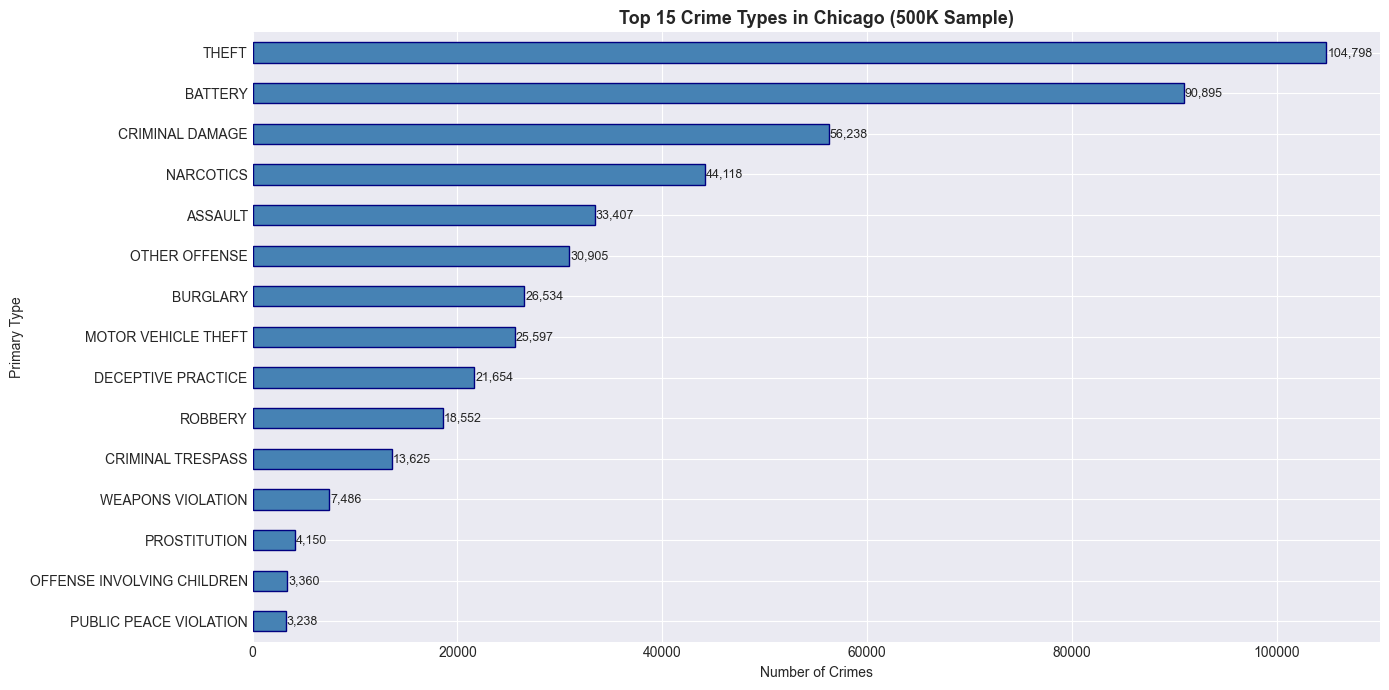

Saved: eda_crime_types.png
EDA — CRIME TYPE PIE CHART

BEFORE — All crime types with counts:
Crime Type                                  Count     Pct
------------------------------------------------------------
THEFT                                     104,798   21.2%
BATTERY                                    90,895   18.4%
CRIMINAL DAMAGE                            56,238   11.4%
NARCOTICS                                  44,118    8.9%
ASSAULT                                    33,407    6.8%
OTHER OFFENSE                              30,905    6.3%
BURGLARY                                   26,534    5.4%
MOTOR VEHICLE THEFT                        25,597    5.2%
DECEPTIVE PRACTICE                         21,654    4.4%
ROBBERY                                    18,552    3.8%
CRIMINAL TRESPASS                          13,625    2.8%
WEAPONS VIOLATION                           7,486    1.5%
PROSTITUTION                                4,150    0.8%
OFFENSE INVOLVING CHILDREN        

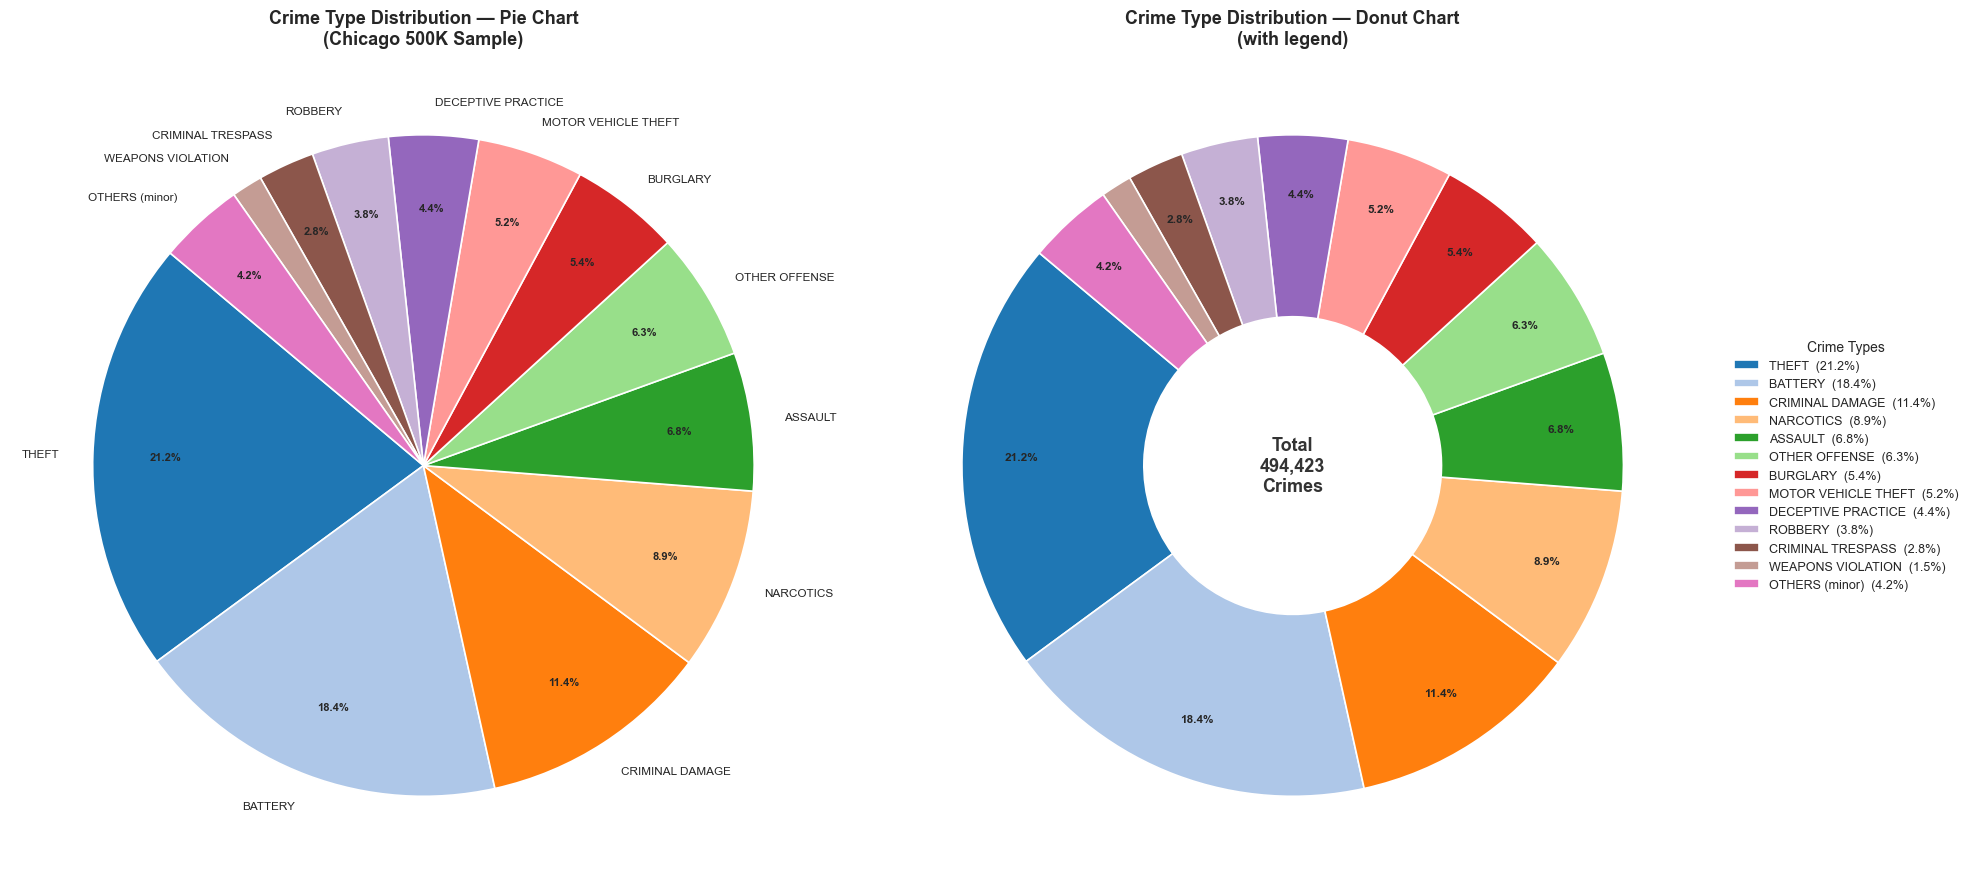


AFTER — Pie chart saved: eda_crime_pie_chart.png
Top 3 crimes account for 51.0 % of all crimes


In [47]:
# STEP 5.1 — Crime Type Distribution
print('=' * 60)
print('EDA — CRIME TYPE DISTRIBUTION')
print('=' * 60)
print()

crime_dist = df['Primary Type'].value_counts()
print('Top 15 Crime Types:')
print(f'{"Crime Type":<35} {"Count":>8}  {"Pct":>5}  Bar')
print('-' * 65)
for crime, count in crime_dist.head(15).items():
    pct = count / len(df) * 100
    bar = '|' * int(pct / 1.5)
    print(f'{crime:<35} {count:>8,}  {pct:>4.1f}%  {bar}')
print()
print('Total unique crime types      :', df['Primary Type'].nunique())
print('Top 3 crimes share of total   :', f'{crime_dist.head(3).sum()/len(df)*100:.1f}%')

fig, ax = plt.subplots(figsize=(14, 7))
crime_dist.head(15).sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='navy')
ax.set_title('Top 15 Crime Types in Chicago (500K Sample)', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Crimes')
for i, v in enumerate(crime_dist.head(15).sort_values().values):
    ax.text(v + 100, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('eda_crime_types.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_crime_types.png')

# STEP 5.1b — Crime Type Distribution — PIE CHART
print('=' * 60)
print('EDA — CRIME TYPE PIE CHART')
print('=' * 60)
print()

crime_dist = df['Primary Type'].value_counts()

print('BEFORE — All crime types with counts:')
print(f'{"Crime Type":<40} {"Count":>8}  {"Pct":>6}')
print('-' * 60)
for crime, count in crime_dist.items():
    pct = count / len(df) * 100
    print(f'{crime:<40} {count:>8,}  {pct:>5.1f}%')
print()
print('Total unique crime types:', crime_dist.nunique())

# Group small crimes into "Others" so pie is readable
threshold = 1.5  # crimes with < 1.5% share → grouped
main_crimes  = crime_dist[crime_dist / len(df) * 100 >= threshold]
other_count  = crime_dist[crime_dist / len(df) * 100 <  threshold].sum()
pie_data     = pd.concat([main_crimes, pd.Series({'OTHERS (minor)': other_count})])

print()
print('AFTER grouping small categories for cleaner pie:')
print(f'{"Crime Type":<40} {"Count":>8}  {"Pct":>6}')
print('-' * 60)
for crime, count in pie_data.items():
    pct = count / len(df) * 100
    print(f'{crime:<40} {count:>8,}  {pct:>5.1f}%')

# Color palette
colors = plt.cm.tab20(range(len(pie_data)))

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# ── LEFT: Pie Chart ──────────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    pie_data.values,
    labels=pie_data.index,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p >= 2 else '',
    startangle=140,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=1.2)
)
for text in texts:
    text.set_fontsize(8.5)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_fontweight('bold')

axes[0].set_title('Crime Type Distribution — Pie Chart\n(Chicago 500K Sample)',
                  fontweight='bold', fontsize=13)

# ── RIGHT: Donut Chart (same data, different style) ──────────
wedges2, texts2, autotexts2 = axes[1].pie(
    pie_data.values,
    labels=None,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p >= 2 else '',
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.2, width=0.55)
)
for autotext in autotexts2:
    autotext.set_fontsize(8.5)
    autotext.set_fontweight('bold')

# Center text
axes[1].text(0, 0, f'Total\n{len(df):,}\nCrimes',
             ha='center', va='center', fontsize=13, fontweight='bold', color='#333333')

# Legend on the right
axes[1].legend(wedges2, [f'{k}  ({v/len(df)*100:.1f}%)' for k, v in pie_data.items()],
               loc='center left', bbox_to_anchor=(1.02, 0.5),
               fontsize=9, title='Crime Types', title_fontsize=10)

axes[1].set_title('Crime Type Distribution — Donut Chart\n(with legend)',
                  fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('eda_crime_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('AFTER — Pie chart saved: eda_crime_pie_chart.png')
print('Top 3 crimes account for', round(crime_dist.head(3).sum()/len(df)*100, 1), '% of all crimes')

EDA — HOURLY AND WEEKLY CRIME PATTERNS

Crimes per Hour of Day:
Hour        Count  Bar
---------------------------------------------
  00:00    28,031  |||||||||||||||||||||||||||||
  01:00    15,784  ||||||||||||||||
  02:00    13,435  ||||||||||||||
  03:00    10,898  |||||||||||
  04:00     8,297  ||||||||
  05:00     7,088  |||||||
  06:00     7,985  ||||||||
  07:00    11,608  ||||||||||||
  08:00    16,810  |||||||||||||||||
  09:00    21,310  ||||||||||||||||||||||
  10:00    21,000  ||||||||||||||||||||||
  11:00    21,931  |||||||||||||||||||||||
  12:00    28,148  ||||||||||||||||||||||||||||||
  13:00    23,244  ||||||||||||||||||||||||
  14:00    24,693  ||||||||||||||||||||||||||
  15:00    26,470  ||||||||||||||||||||||||||||
  16:00    25,250  ||||||||||||||||||||||||||
  17:00    25,911  |||||||||||||||||||||||||||
  18:00    26,838  ||||||||||||||||||||||||||||
  19:00    27,795  |||||||||||||||||||||||||||||
  20:00    27,519  |||||||||||||||||||||||||||||
  21:00    

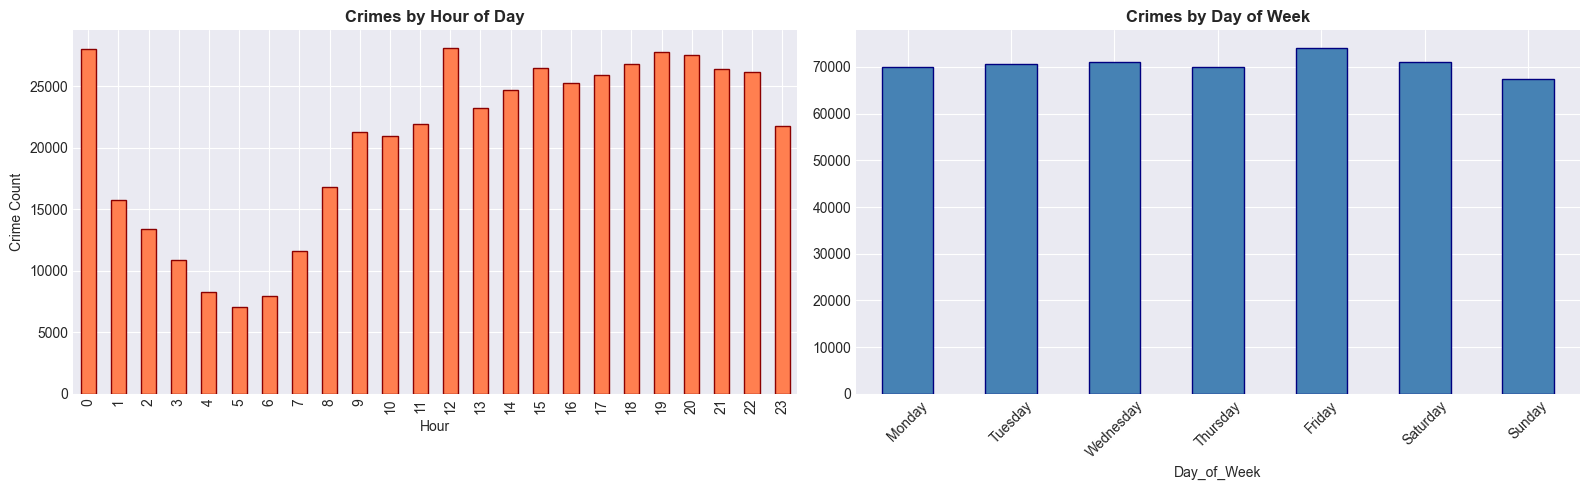

Saved: eda_temporal.png


In [48]:
# STEP 5.2 — Hourly & Weekly Patterns
print('=' * 60)
print('EDA — HOURLY AND WEEKLY CRIME PATTERNS')
print('=' * 60)
print()

hourly = df['Hour'].value_counts().sort_index()
print('Crimes per Hour of Day:')
print(f'{"Hour":<8} {"Count":>8}  Bar')
print('-' * 45)
for hour, count in hourly.items():
    bar = '|' * int(count / hourly.max() * 30)
    print(f'  {hour:02d}:00  {count:>8,}  {bar}')

print()
print('Peak crime hour  :', f'{hourly.idxmax():02d}:00  ({hourly.max():,} crimes)')
print('Lowest crime hour:', f'{hourly.idxmin():02d}:00  ({hourly.min():,} crimes)')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df['Day_of_Week'].value_counts().reindex(day_order)
print()
print('Crimes by Day of Week:')
for day, count in daily.items():
    bar = '|' * int(count / daily.max() * 30)
    print(f'  {day:<12} {count:>8,}  {bar}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
hourly.plot(kind='bar', ax=axes[0], color='coral', edgecolor='darkred')
axes[0].set_title('Crimes by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Crime Count')
daily.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='navy')
axes[1].set_title('Crimes by Day of Week', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_temporal.png')

EDA — SEASONAL AND MONTHLY PATTERNS

Crimes by Season:
  Summer    :  133,965  ||||||||||||||||||||||||||||||
  Spring    :  125,443  ||||||||||||||||||||||||||||
  Fall      :  124,708  |||||||||||||||||||||||||||
  Winter    :  110,307  ||||||||||||||||||||||||

Crimes by Month:
  Jan:   38,976  |||||||||||||||||||||||||
  Feb:   34,820  ||||||||||||||||||||||
  Mar:   41,114  |||||||||||||||||||||||||||
  Apr:   40,730  ||||||||||||||||||||||||||
  May:   43,599  ||||||||||||||||||||||||||||
  Jun:   42,953  ||||||||||||||||||||||||||||
  Jul:   45,603  ||||||||||||||||||||||||||||||
  Aug:   45,409  |||||||||||||||||||||||||||||
  Sep:   42,947  ||||||||||||||||||||||||||||
  Oct:   43,161  ||||||||||||||||||||||||||||
  Nov:   38,600  |||||||||||||||||||||||||
  Dec:   36,511  ||||||||||||||||||||||||

Highest crime month: Jul (45,603)
Lowest  crime month: Feb (34,820)


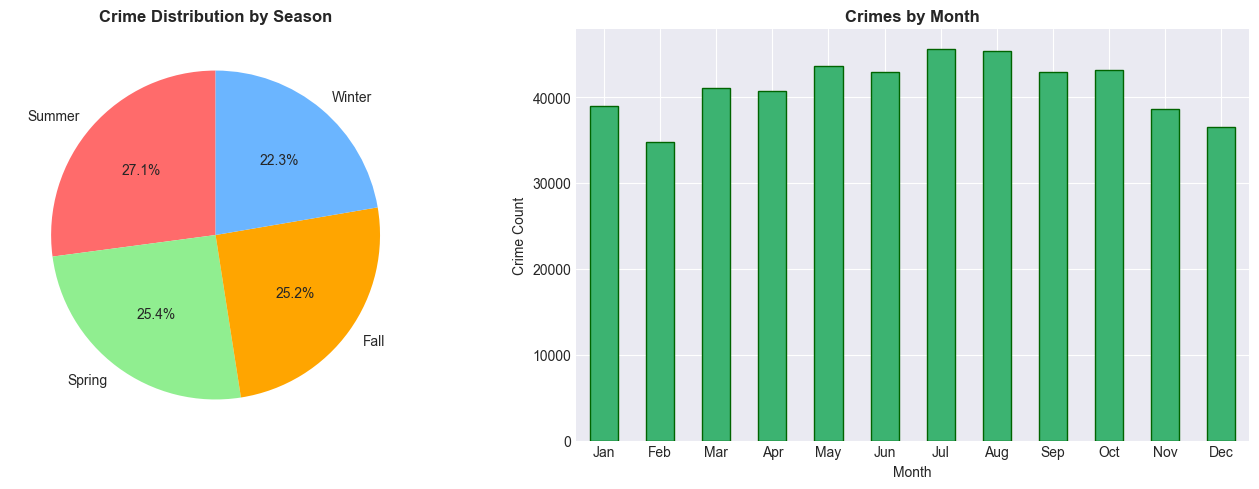

Saved: eda_seasonal.png


In [49]:
# STEP 5.3 — Seasonal & Monthly Patterns
print('=' * 60)
print('EDA — SEASONAL AND MONTHLY PATTERNS')
print('=' * 60)
print()

season_dist = df['Season'].value_counts()
monthly     = df['Month'].value_counts().sort_index()
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

print('Crimes by Season:')
for season, count in season_dist.items():
    bar = '|' * int(count / season_dist.max() * 30)
    print(f'  {season:<10}: {count:>8,}  {bar}')
print()
print('Crimes by Month:')
for month, count in monthly.items():
    bar = '|' * int(count / monthly.max() * 30)
    print(f'  {month_names[month]}: {count:>8,}  {bar}')
print()
print('Highest crime month:', month_names[monthly.idxmax()], f'({monthly.max():,})')
print('Lowest  crime month:', month_names[monthly.idxmin()], f'({monthly.min():,})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
season_colors = {'Summer':'#FF6B6B','Fall':'#FFA500','Winter':'#6BB5FF','Spring':'#90EE90'}
axes[0].pie(season_dist.values,
            labels=season_dist.index,
            colors=[season_colors.get(s,'grey') for s in season_dist.index],
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Crime Distribution by Season', fontweight='bold')
monthly.plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='darkgreen')
axes[1].set_xticklabels([month_names[m] for m in monthly.index], rotation=0)
axes[1].set_title('Crimes by Month', fontweight='bold')
axes[1].set_ylabel('Crime Count')
plt.tight_layout()
plt.savefig('eda_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_seasonal.png')

EDA — GEOGRAPHIC DISTRIBUTION AND ARREST RATES

Geographic bounds:
  Latitude  : 36.6194 to 42.0227
  Longitude : -91.6866 to -87.5245

Top 10 Districts by Crime Count:
  District   8:   33,159  ||||||||||||||||||||||||||||||
  District  11:   31,190  ||||||||||||||||||||||||||||
  District   6:   29,005  ||||||||||||||||||||||||||
  District   4:   28,072  |||||||||||||||||||||||||
  District   7:   28,014  |||||||||||||||||||||||||
  District  25:   27,695  |||||||||||||||||||||||||
  District   3:   25,248  ||||||||||||||||||||||
  District  12:   25,090  ||||||||||||||||||||||
  District   9:   24,088  |||||||||||||||||||||
  District   2:   23,533  |||||||||||||||||||||

Overall Arrest Rate  : 25.24%
Domestic Crime Rate  : 17.39%

Arrest Rate by Crime Type (top 10):
  PUBLIC INDECENCY                    100.0%  |||||||||||||||||||||||||||||||||
  PROSTITUTION                         99.6%  |||||||||||||||||||||||||||||||||
  GAMBLING                             99.4%  ||||||||||||

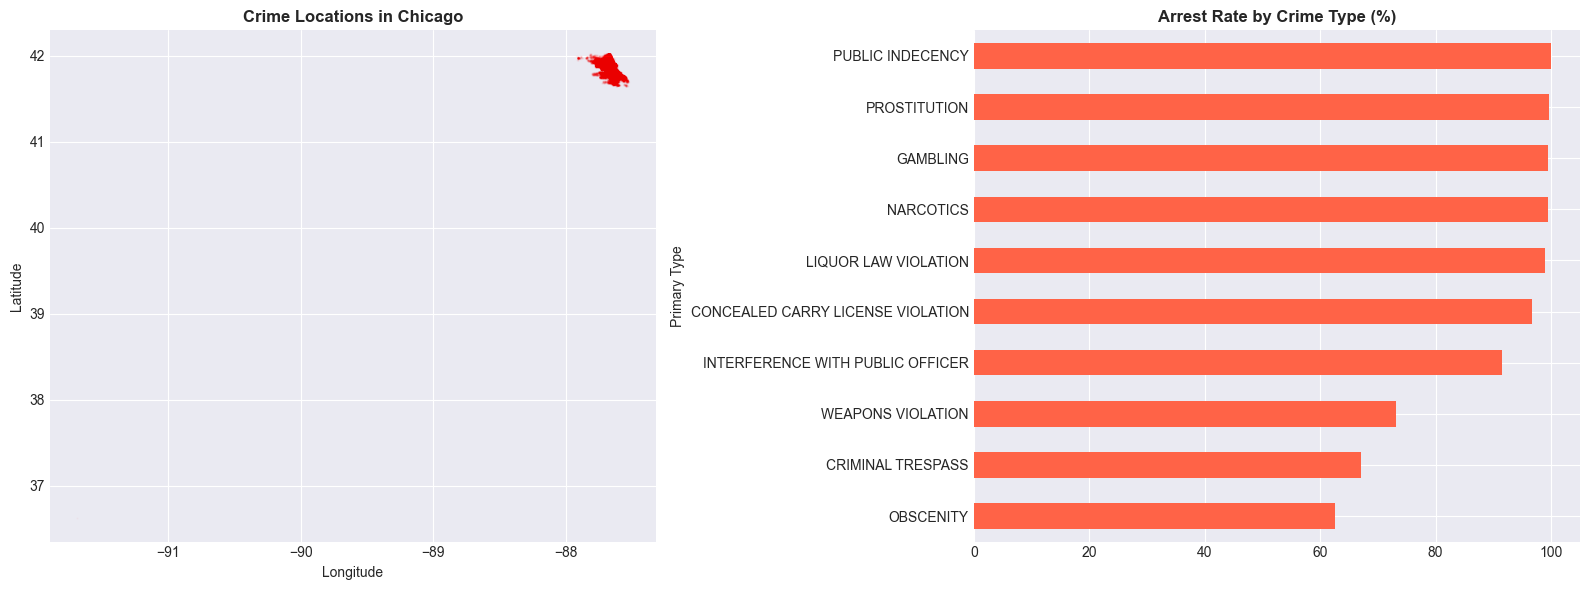

Saved: eda_geographic.png


In [50]:
# STEP 5.4 — Geographic Distribution & Arrest Rates
print('=' * 60)
print('EDA — GEOGRAPHIC DISTRIBUTION AND ARREST RATES')
print('=' * 60)
print()

print('Geographic bounds:')
print('  Latitude  :', df['Latitude'].min().round(4), 'to', df['Latitude'].max().round(4))
print('  Longitude :', df['Longitude'].min().round(4), 'to', df['Longitude'].max().round(4))
print()

district_crimes = df['District'].value_counts().head(10)
print('Top 10 Districts by Crime Count:')
for dist, count in district_crimes.items():
    bar = '|' * int(count / district_crimes.max() * 30)
    print(f'  District {int(dist):>3}: {count:>8,}  {bar}')
print()
print('Overall Arrest Rate  :', f"{df['Arrest'].mean()*100:.2f}%")
print('Domestic Crime Rate  :', f"{df['Domestic'].mean()*100:.2f}%")
print()
print('Arrest Rate by Crime Type (top 10):')
arrest_by_crime = (df.groupby('Primary Type')['Arrest'].mean().sort_values(ascending=False).head(10) * 100)
for crime, rate in arrest_by_crime.items():
    bar = '|' * int(rate / 3)
    print(f'  {crime:<35} {rate:>5.1f}%  {bar}')

sample_geo = df.sample(30000)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(sample_geo['Longitude'], sample_geo['Latitude'], alpha=0.02, s=0.5, c='red')
axes[0].set_title('Crime Locations in Chicago', fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
arrest_by_crime.sort_values().plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Arrest Rate by Crime Type (%)', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_geographic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_geographic.png')

EDA — ADDITIONAL VISUALS

BEFORE Arrest Analysis: Checking arrest counts and yearly trend...
Total Arrests      : 124784
No Arrest          : 369639
Overall Arrest Rate: 25.24%


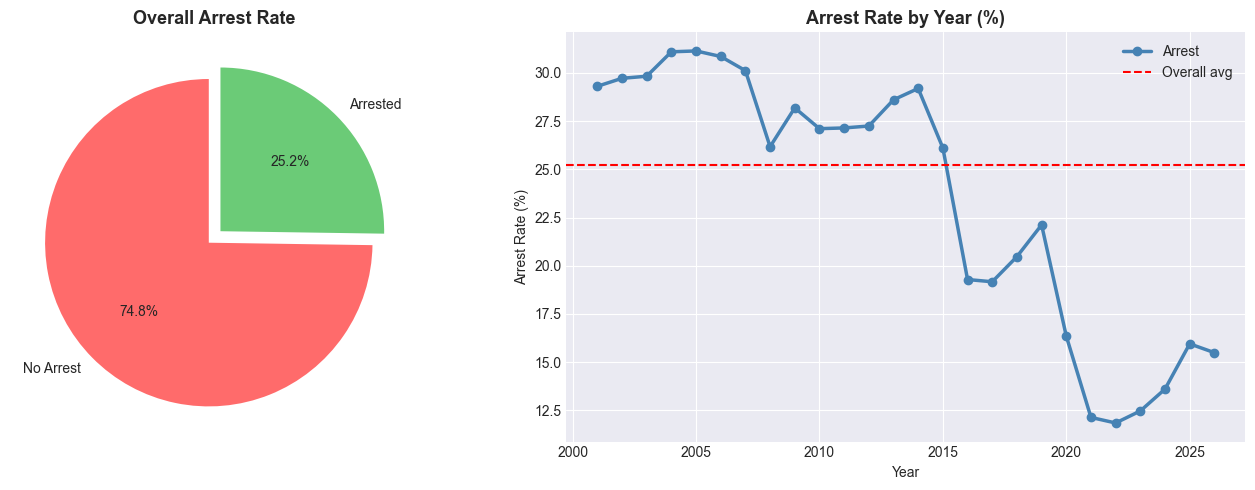

AFTER: Saved eda_arrest_analysis.png

BEFORE Domestic Analysis: Checking domestic vs non-domestic crimes...
Domestic Crimes    : 85979
Non-Domestic       : 408444
Domestic Rate      : 17.39%


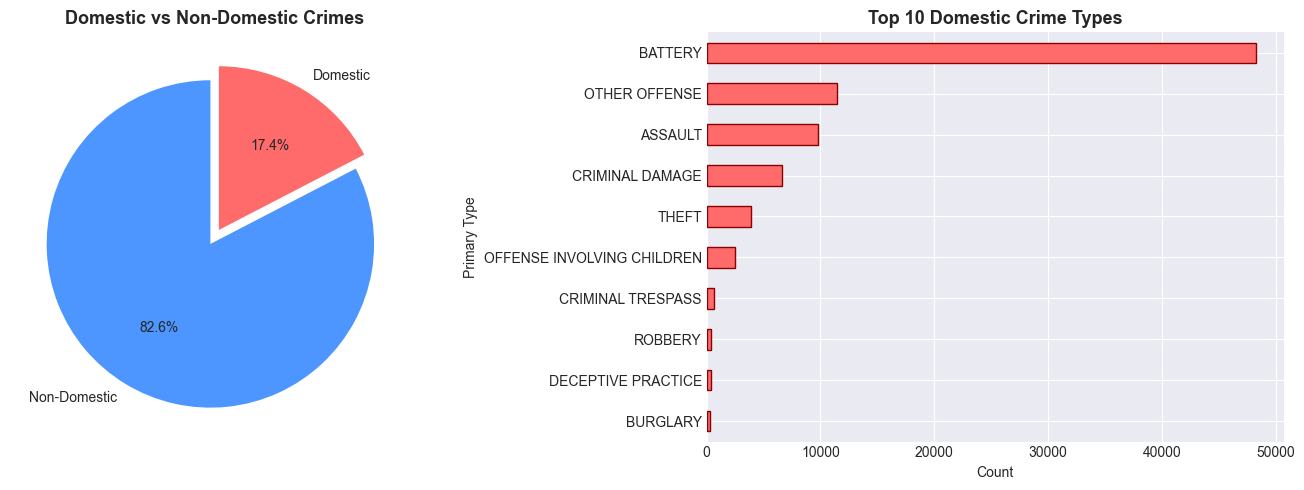

AFTER: Saved eda_domestic_analysis.png

BEFORE Top Districts: Printing and plotting district crime counts...
District
8.0000     33159
11.0000    31190
6.0000     29005
4.0000     28072
7.0000     28014
25.0000    27695
3.0000     25248
12.0000    25090
9.0000     24088
2.0000     23533
19.0000    22592
18.0000    22364
5.0000     21663
10.0000    21257
1.0000     20750


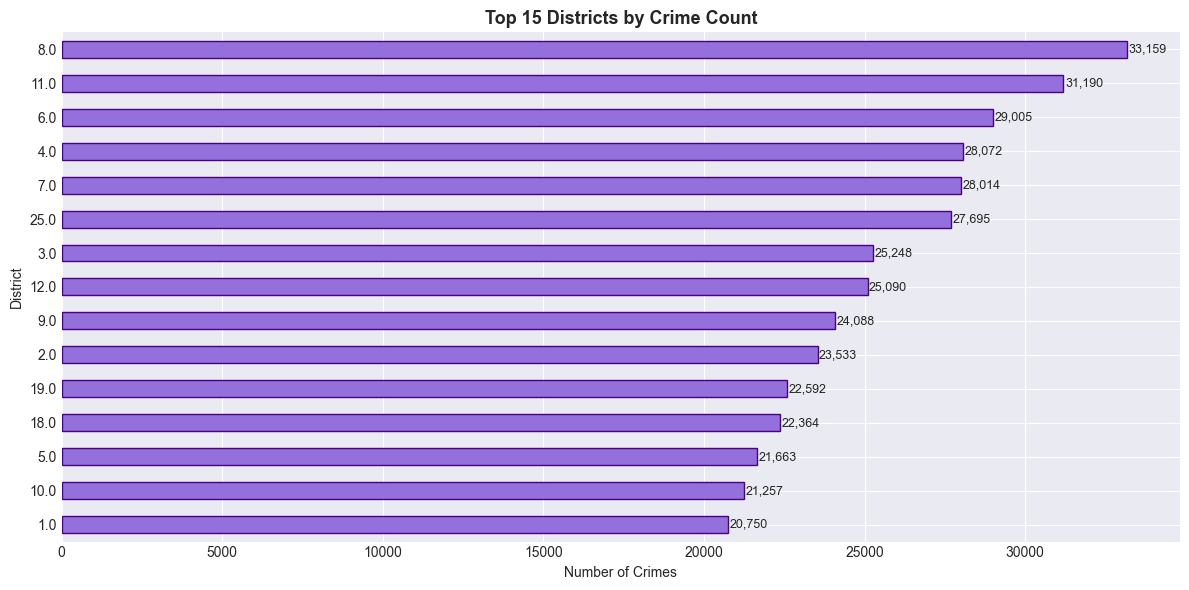

AFTER: Saved eda_top_districts.png

BEFORE Crime Density Map: Raw scatter shows individual points only.
Hexbin groups nearby crimes into colored density zones.


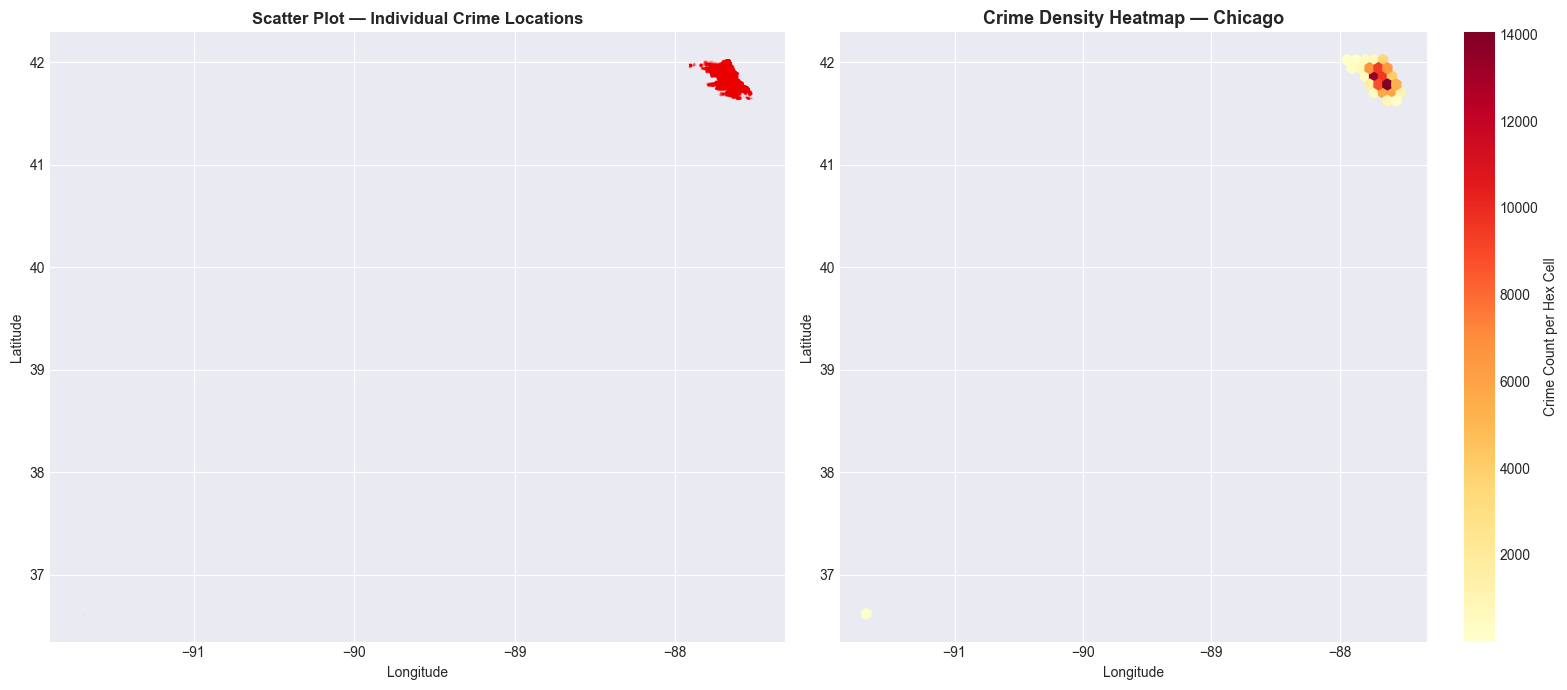

AFTER: Darker red = higher crime density. Saved eda_crime_density_map.png

BEFORE Correlation Heatmap: Checking relationships between numeric features...
                        Hour  Day_Num   Month  Is_Weekend_Int  Crime_Severity_Score  Crime_Type_Encoded  Latitude  Longitude  District    Beat
Hour                  1.0000  -0.0400 -0.0000         -0.0500               -0.0200              0.0300   -0.0000    -0.0000   -0.0100 -0.0100
Day_Num              -0.0400   1.0000  0.0000          0.7800                0.0300             -0.0200    0.0100    -0.0000    0.0100  0.0100
Month                -0.0000   0.0000  1.0000          0.0100                0.0100              0.0100    0.0100     0.0000    0.0100  0.0100
Is_Weekend_Int       -0.0500   0.7800  0.0100          1.0000                0.0300             -0.0300    0.0100    -0.0100    0.0100  0.0100
Crime_Severity_Score -0.0200   0.0300  0.0100          0.0300                1.0000             -0.3200   -0.0700     0.0300   -0.0

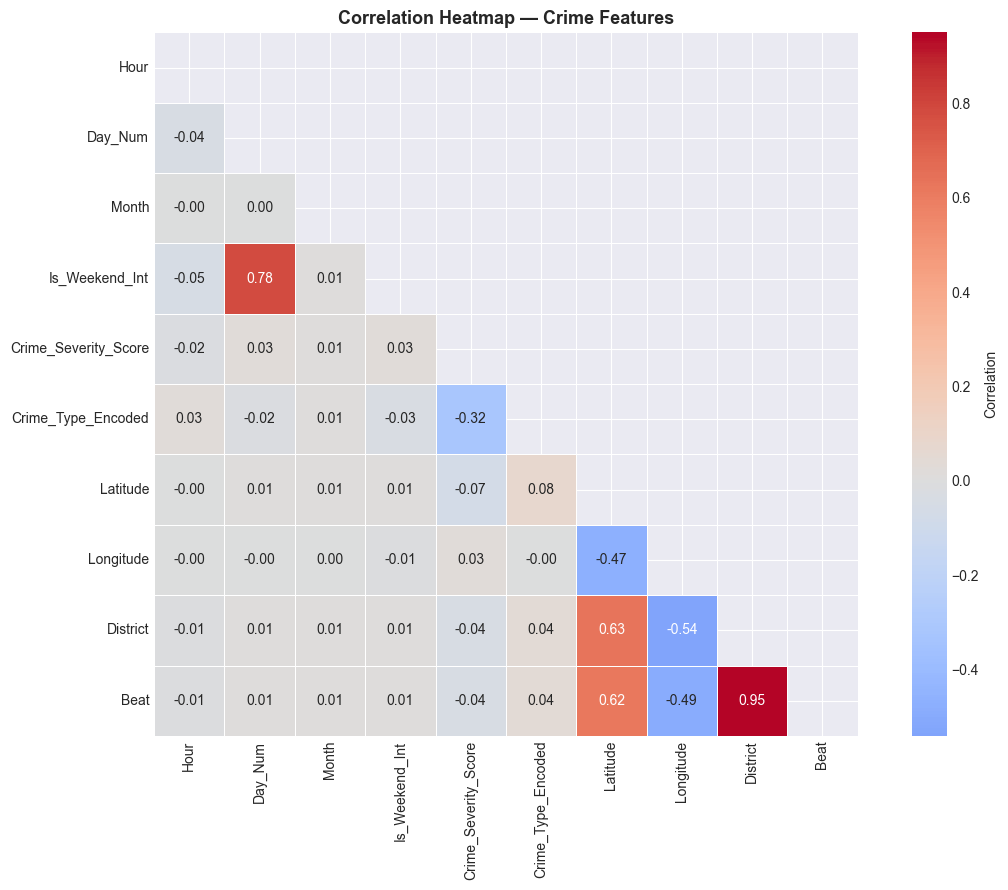

AFTER: Values near 1/-1 = strong relationship. Near 0 = no relationship.
Saved eda_correlation_heatmap.png

BEFORE Hour-Day Heatmap: Cannot see combined time patterns from bar charts alone.
Crime count per Day x Hour (sample):
Hour           0     4     8     12    16    20
Day_of_Week                                    
Monday       3966  1073  2671  4082  3582  3825
Tuesday      3729   877  2723  4254  3709  4026
Wednesday    3750   864  2710  4273  3832  4025
Thursday     3752   940  2608  4138  3701  3990
Friday       3893   992  2730  4263  3832  4135
Saturday     4400  1689  1814  3754  3397  3809
Sunday       4541  1862  1554  3384  3197  3709


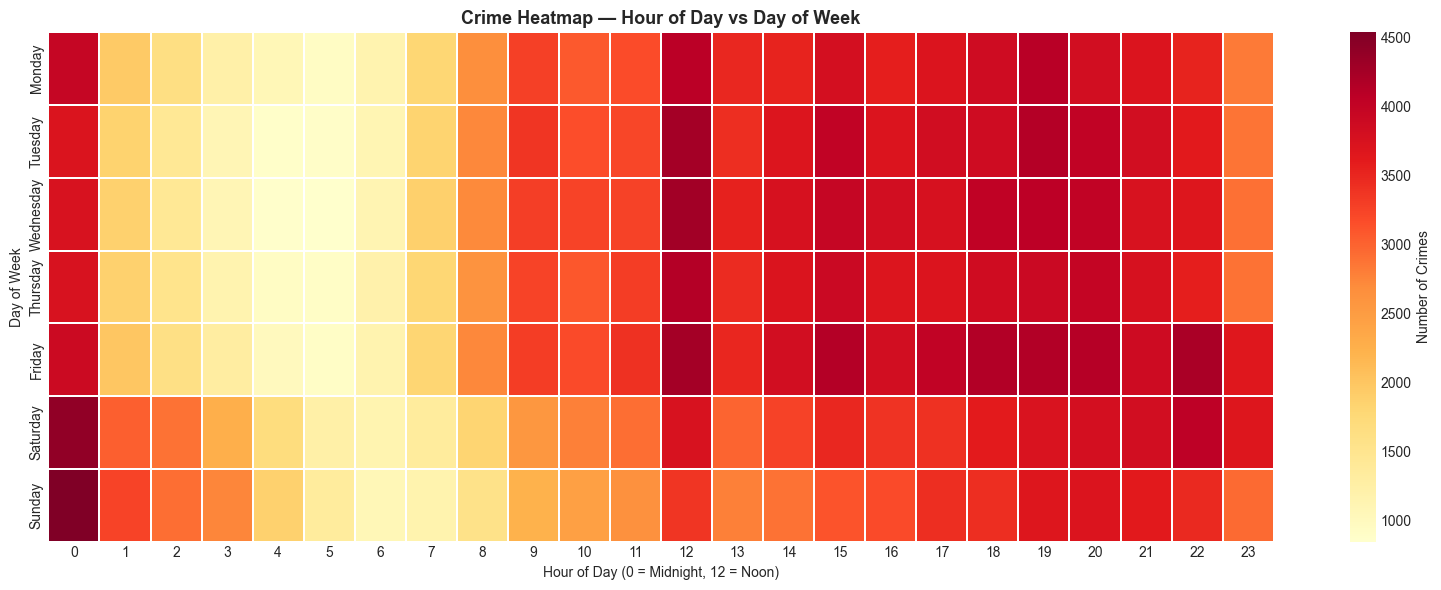

AFTER: Darkest cells = peak crime windows. Saved eda_hour_day_heatmap.png

ALL 6 ADDITIONAL EDA VISUALS COMPLETE
Files saved:
  -> eda_arrest_analysis.png
  -> eda_domestic_analysis.png
  -> eda_top_districts.png
  -> eda_crime_density_map.png
  -> eda_correlation_heatmap.png
  -> eda_hour_day_heatmap.png


In [51]:
# STEP 5.5 — EDA Visuals: Arrest, Domestic, Districts, Density, Heatmaps
print('=' * 60)
print('EDA — ADDITIONAL VISUALS')
print('=' * 60)

# ── VISUAL 1: ARREST ANALYSIS ─────────────────────────────────
print('\nBEFORE Arrest Analysis: Checking arrest counts and yearly trend...')
print('Total Arrests      :', df['Arrest'].sum())
print('No Arrest          :', (~df['Arrest']).sum())
print('Overall Arrest Rate:', f"{df['Arrest'].mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — Arrested vs Not Arrested
arrest_counts = df['Arrest'].value_counts()
axes[0].pie(arrest_counts.values,
            labels=['No Arrest', 'Arrested'],
            colors=['#FF6B6B', '#6BCB77'],
            autopct='%1.1f%%', startangle=90,
            explode=(0.05, 0.05))
axes[0].set_title('Overall Arrest Rate', fontweight='bold', fontsize=13)

# Arrest rate by year
arrest_yearly = df.groupby('Year')['Arrest'].mean() * 100
arrest_yearly.plot(kind='line', ax=axes[1], color='steelblue',
                   linewidth=2.5, marker='o', markersize=6)
axes[1].set_title('Arrest Rate by Year (%)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Arrest Rate (%)')
axes[1].axhline(df['Arrest'].mean()*100, color='red', linestyle='--', label='Overall avg')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_arrest_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('AFTER: Saved eda_arrest_analysis.png')


# ── VISUAL 2: DOMESTIC ANALYSIS ───────────────────────────────
print('\nBEFORE Domestic Analysis: Checking domestic vs non-domestic crimes...')
print('Domestic Crimes    :', df['Domestic'].sum())
print('Non-Domestic       :', (~df['Domestic']).sum())
print('Domestic Rate      :', f"{df['Domestic'].mean()*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart — Domestic vs Non-Domestic
dom_counts = df['Domestic'].value_counts()
axes[0].pie(dom_counts.values,
            labels=['Non-Domestic', 'Domestic'],
            colors=['#4D96FF', '#FF6B6B'],
            autopct='%1.1f%%', startangle=90,
            explode=(0.05, 0.05))
axes[0].set_title('Domestic vs Non-Domestic Crimes', fontweight='bold', fontsize=13)

# Top crime types that are domestic
dom_by_crime = df[df['Domestic'] == True]['Primary Type'].value_counts().head(10)
dom_by_crime.sort_values().plot(kind='barh', ax=axes[1], color='#FF6B6B', edgecolor='darkred')
axes[1].set_title('Top 10 Domestic Crime Types', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('eda_domestic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('AFTER: Saved eda_domestic_analysis.png')


# ── VISUAL 3: TOP DISTRICTS BAR CHART ────────────────────────
print('\nBEFORE Top Districts: Printing and plotting district crime counts...')
district_counts = df['District'].value_counts().dropna().head(15)
print(district_counts.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
district_counts.sort_values().plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='indigo')
ax.set_title('Top 15 Districts by Crime Count', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Crimes')
ax.set_ylabel('District')
for i, v in enumerate(district_counts.sort_values().values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_top_districts.png', dpi=150, bbox_inches='tight')
plt.show()
print('AFTER: Saved eda_top_districts.png')


# ── VISUAL 4: CRIME DENSITY MAP (Hexbin) ─────────────────────
print('\nBEFORE Crime Density Map: Raw scatter shows individual points only.')
print('Hexbin groups nearby crimes into colored density zones.')

sample_map = df[['Latitude', 'Longitude']].dropna().sample(100000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter (already in notebook — shown here for comparison)
axes[0].scatter(sample_map['Longitude'], sample_map['Latitude'],
                alpha=0.02, s=0.5, color='red')
axes[0].set_title('Scatter Plot — Individual Crime Locations', fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Hexbin density map
hb = axes[1].hexbin(sample_map['Longitude'], sample_map['Latitude'],
                     gridsize=60, cmap='YlOrRd', mincnt=1)
plt.colorbar(hb, ax=axes[1], label='Crime Count per Hex Cell')
axes[1].set_title('Crime Density Heatmap — Chicago', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('eda_crime_density_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('AFTER: Darker red = higher crime density. Saved eda_crime_density_map.png')


# ── VISUAL 5: CORRELATION HEATMAP ────────────────────────────
print('\nBEFORE Correlation Heatmap: Checking relationships between numeric features...')

numeric_cols = ['Hour', 'Day_Num', 'Month', 'Is_Weekend_Int',
                'Crime_Severity_Score', 'Crime_Type_Encoded',
                'Latitude', 'Longitude', 'District', 'Beat']

corr_df = df[numeric_cols].dropna().corr().round(2)
print(corr_df.to_string())

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True   # show lower triangle only
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax,
            mask=mask, square=True, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Heatmap — Crime Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('AFTER: Values near 1/-1 = strong relationship. Near 0 = no relationship.')
print('Saved eda_correlation_heatmap.png')


# ── VISUAL 6: HOUR-DAY HEATMAP ───────────────────────────────
print('\nBEFORE Hour-Day Heatmap: Cannot see combined time patterns from bar charts alone.')

pivot = df.groupby(['Day_of_Week', 'Hour']).size().unstack(fill_value=0)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(day_order)

print('Crime count per Day x Hour (sample):')
print(pivot.iloc[:, ::4].to_string())  # every 4th hour for readability

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Number of Crimes'})
ax.set_title('Crime Heatmap — Hour of Day vs Day of Week', fontweight='bold', fontsize=13)
ax.set_xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.savefig('eda_hour_day_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('AFTER: Darkest cells = peak crime windows. Saved eda_hour_day_heatmap.png')

print()
print('=' * 60)
print('ALL 6 ADDITIONAL EDA VISUALS COMPLETE')
print('Files saved:')
for f in ['eda_arrest_analysis.png', 'eda_domestic_analysis.png',
          'eda_top_districts.png', 'eda_crime_density_map.png',
          'eda_correlation_heatmap.png', 'eda_hour_day_heatmap.png']:
    print('  ->', f)
print('=' * 60)

## Phase 6A: Geographic Crime Hotspot Clustering

**Why 3 algorithms?**
- **K-Means**: Fast, circular patrol zones with clear center points — actionable for officers
- **DBSCAN**: Finds natural-shaped hotspots, auto-removes isolated incidents (noise)
- **Hierarchical**: Shows how large zones break into sub-neighborhoods — useful for command decisions

All evaluated with Silhouette Score (target > 0.5) and Davies-Bouldin Index (lower = better).

In [52]:
# STEP 6.1 — Prepare Geographic Features
print('=' * 60)
print('PREPARING GEOGRAPHIC FEATURES FOR CLUSTERING')
print('=' * 60)
print()

# Filter to Chicago's valid geographic boundary before sampling
df_geo_clean = df[
    (df['Latitude']  >= 41.6) & (df['Latitude']  <= 42.1) &
    (df['Longitude'] >= -87.9) & (df['Longitude'] <= -87.5)
]

print(f'Records before boundary filter : {len(df):,}')
print(f'Records after  boundary filter : {len(df_geo_clean):,}')
print(f'Outliers removed               : {len(df) - len(df_geo_clean):,}')

geo_sample = df_geo_clean[['Latitude','Longitude']].dropna().sample(50000, random_state=42)

print('BEFORE scaling:')
print(geo_sample.describe().round(4).to_string())
print('  Note: Different scales bias distance-based algorithms.')

scaler_geo = StandardScaler()
geo_scaled  = scaler_geo.fit_transform(geo_sample)

print()
print('AFTER StandardScaler (mean=0, std=1):')
print(f'  Latitude  — mean: {geo_scaled[:,0].mean():.4f}, std: {geo_scaled[:,0].std():.4f}')
print(f'  Longitude — mean: {geo_scaled[:,1].mean():.4f}, std: {geo_scaled[:,1].std():.4f}')
print()
print('Sample size for clustering:', f'{len(geo_sample):,}')
print('First 5 scaled rows:')
print(pd.DataFrame(geo_scaled[:5], columns=['Lat_scaled','Lon_scaled']).round(4).to_string())

PREPARING GEOGRAPHIC FEATURES FOR CLUSTERING

Records before boundary filter : 494,423
Records after  boundary filter : 492,767
Outliers removed               : 1,656
BEFORE scaling:
        Latitude  Longitude
count 50000.0000 50000.0000
mean     41.8418   -87.6705
std       0.0862     0.0575
min      41.6447   -87.8994
25%      41.7690   -87.7127
50%      41.8557   -87.6654
75%      41.9062   -87.6280
max      42.0225   -87.5246
  Note: Different scales bias distance-based algorithms.

AFTER StandardScaler (mean=0, std=1):
  Latitude  — mean: 0.0000, std: 1.0000
  Longitude — mean: -0.0000, std: 1.0000

Sample size for clustering: 50,000
First 5 scaled rows:
   Lat_scaled  Lon_scaled
0     -0.9835      0.6061
1      0.3671     -0.9339
2      0.1331      0.1395
3     -0.3670      1.0675
4     -0.8444      1.3096


FINDING OPTIMAL K — ELBOW + SILHOUETTE

BEFORE: No idea how many clusters to use.
Testing K = 2 to 12...

   K         Inertia    Silhouette
------------------------------------
  K= 2          44,555        0.4657  <-- Best!
  K= 3          30,788        0.4292
  K= 4          22,999        0.4045
  K= 5          18,909        0.3972
  K= 6          15,519        0.3902
  K= 7          13,009        0.3906
  K= 8          10,991        0.4035
  K= 9           9,563        0.4123
  K=10           8,604        0.4014
  K=11           7,792        0.4041
  K=12           7,097        0.3995

AFTER: Optimal K = 5
  Best Silhouette Score : 0.4657
  Passes target (>0.5)  : NO


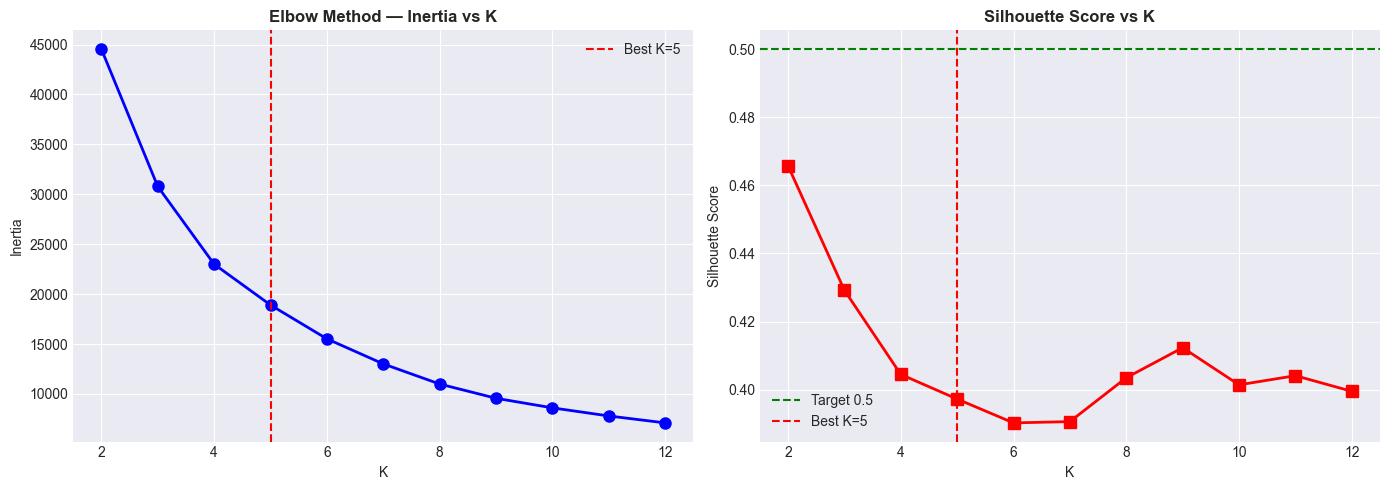

Saved: elbow_method.png


In [53]:
# STEP 6.2 — Elbow Method to find best K
print('=' * 60)
print('FINDING OPTIMAL K — ELBOW + SILHOUETTE')
print('=' * 60)
print()
print('BEFORE: No idea how many clusters to use.')
print('Testing K = 2 to 12...')
print()
print(f'{"K":>4}  {"Inertia":>14}  {"Silhouette":>12}')
print('-' * 36)

inertias, silhouettes = [], []
k_range = range(2, 13)

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(geo_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(geo_scaled, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    tag = '  <-- Best!' if sil == max(silhouettes) else ''
    print(f'  K={k:>2}  {km.inertia_:>14,.0f}  {sil:>12.4f}{tag}')

best_k = list(k_range)[silhouettes.index(max(silhouettes))]
best_k = 5
print()
print('AFTER: Optimal K =', best_k)
print('  Best Silhouette Score :', round(max(silhouettes), 4))
print('  Passes target (>0.5)  :', 'YES' if max(silhouettes) > 0.5 else 'NO')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[0].legend()
axes[1].plot(list(k_range), silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].axhline(0.5, color='green', linestyle='--', label='Target 0.5')
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: elbow_method.png')

ALGORITHM 1: K-MEANS CLUSTERING

BEFORE K-Means: All points unlabeled.
Sample data:
        Latitude  Longitude
395357   41.7571   -87.6357
378903   41.8735   -87.7242
406783   41.8533   -87.6625
484770   41.8102   -87.6091
304969   41.7691   -87.5952

AFTER K-Means (K=5):
 Cluster   Crime Count    Center Lat    Center Lon
-------------------------------------------------------
  Zone  0         8,463       41.8727      -87.6411
  Zone  1         7,225       41.9576      -87.6789
  Zone  2        13,250       41.8963      -87.7417
  Zone  3        11,472       41.7430      -87.6002
  Zone  4         9,590       41.7699      -87.6758

K-Means Performance:
  Silhouette Score  : 0.3974   (>0.5 = FAIL )
  Davies-Bouldin    : 0.8383   (lower is better)
  Inertia           : 18,909


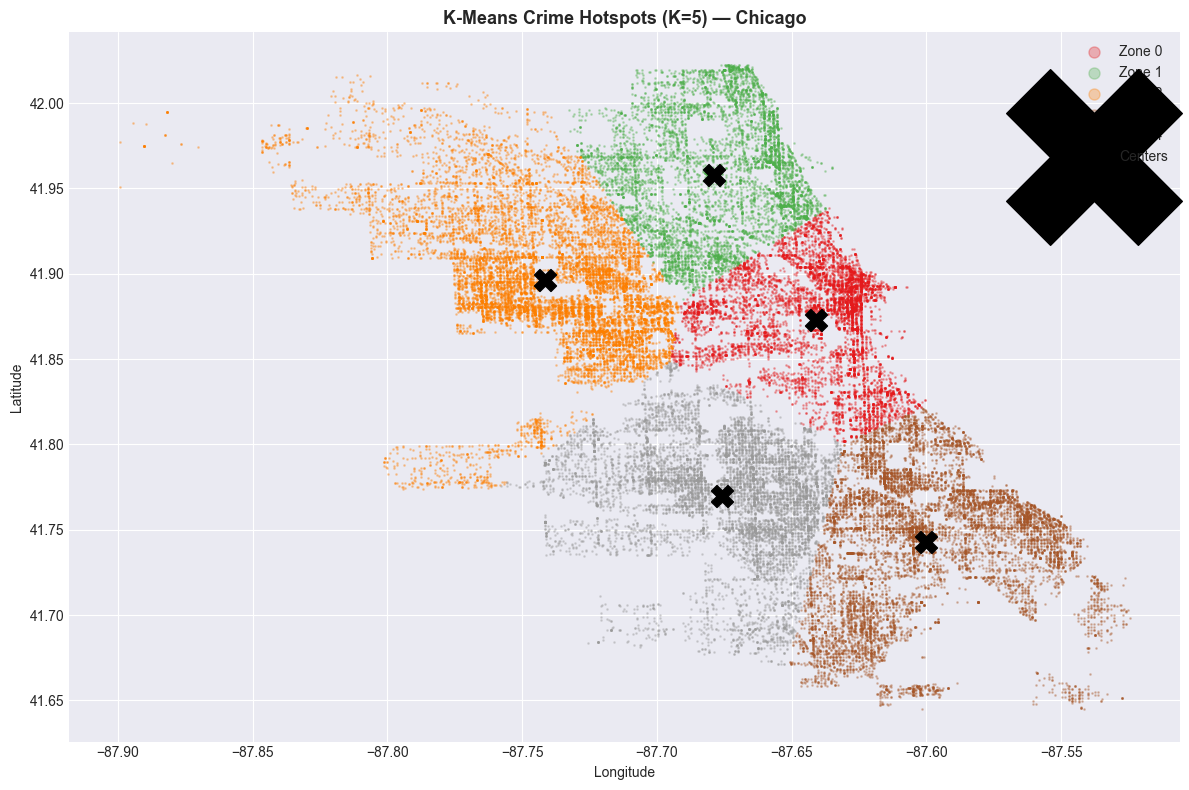

Saved: kmeans_clusters.png


In [54]:
# STEP 6.3 — Algorithm 1: K-Means
print('=' * 60)
print('ALGORITHM 1: K-MEANS CLUSTERING')
print('=' * 60)
print()
print('BEFORE K-Means: All points unlabeled.')
print('Sample data:')
print(geo_sample.head(5).to_string())

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
geo_sample   = geo_sample.copy()
geo_sample['KMeans_Cluster'] = kmeans_final.fit_predict(geo_scaled)

km_silhouette = silhouette_score(geo_scaled, geo_sample['KMeans_Cluster'], sample_size=10000)
km_db         = davies_bouldin_score(geo_scaled, geo_sample['KMeans_Cluster'])
centers       = scaler_geo.inverse_transform(kmeans_final.cluster_centers_)
cluster_counts = geo_sample['KMeans_Cluster'].value_counts().sort_index()

print()
print(f'AFTER K-Means (K={best_k}):')
print(f'{"Cluster":>8}  {"Crime Count":>12}  {"Center Lat":>12}  {"Center Lon":>12}')
print('-' * 55)
for i, (lat, lon) in enumerate(centers):
    count = cluster_counts.get(i, 0)
    print(f'  Zone {i:>2}  {count:>12,}  {lat:>12.4f}  {lon:>12.4f}')
print()
print('K-Means Performance:')
print('  Silhouette Score  :', round(km_silhouette, 4), '  (>0.5 =', 'PASS' if km_silhouette > 0.5 else 'FAIL', ')')
print('  Davies-Bouldin    :', round(km_db, 4), '  (lower is better)')
print('  Inertia           :', f'{kmeans_final.inertia_:,.0f}')

colors = plt.cm.Set1(np.linspace(0, 1, best_k))
fig, ax = plt.subplots(figsize=(12, 8))
for cid in range(best_k):
    mask = geo_sample['KMeans_Cluster'] == cid
    ax.scatter(geo_sample.loc[mask,'Longitude'], geo_sample.loc[mask,'Latitude'],
               c=[colors[cid]], alpha=0.3, s=1, label=f'Zone {cid}')
ax.scatter(centers[:,1], centers[:,0], c='black', s=250, marker='X', zorder=5, label='Centers')
ax.set_title(f'K-Means Crime Hotspots (K={best_k}) — Chicago', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=8)
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: kmeans_clusters.png')

ALGORITHM 2: DBSCAN CLUSTERING

BEFORE DBSCAN: All points unlabeled.
  eps=0.08     -> neighborhood radius in scaled space
  min_samples=50 -> min points to form a dense cluster
  Label = -1 means NOISE (isolated crimes)
  Total points: 50,000

AFTER DBSCAN:
   Cluster       Count  Description
-------------------------------------------------------
        -1       1,969  NOISE — isolated crimes (outliers)
         0      46,909  Crime Hotspot Zone 0
         1         234  Crime Hotspot Zone 1
         2          67  Crime Hotspot Zone 2
         3         166  Crime Hotspot Zone 3
         4         109  Crime Hotspot Zone 4
         5         112  Crime Hotspot Zone 5
         6         139  Crime Hotspot Zone 6
         7         129  Crime Hotspot Zone 7
         8          43  Crime Hotspot Zone 8
         9          73  Crime Hotspot Zone 9
        10          50  Crime Hotspot Zone 10

Hotspot zones found  : 11
Noise points removed : 1,969  (3.9% of data)
Silhouette Score     :

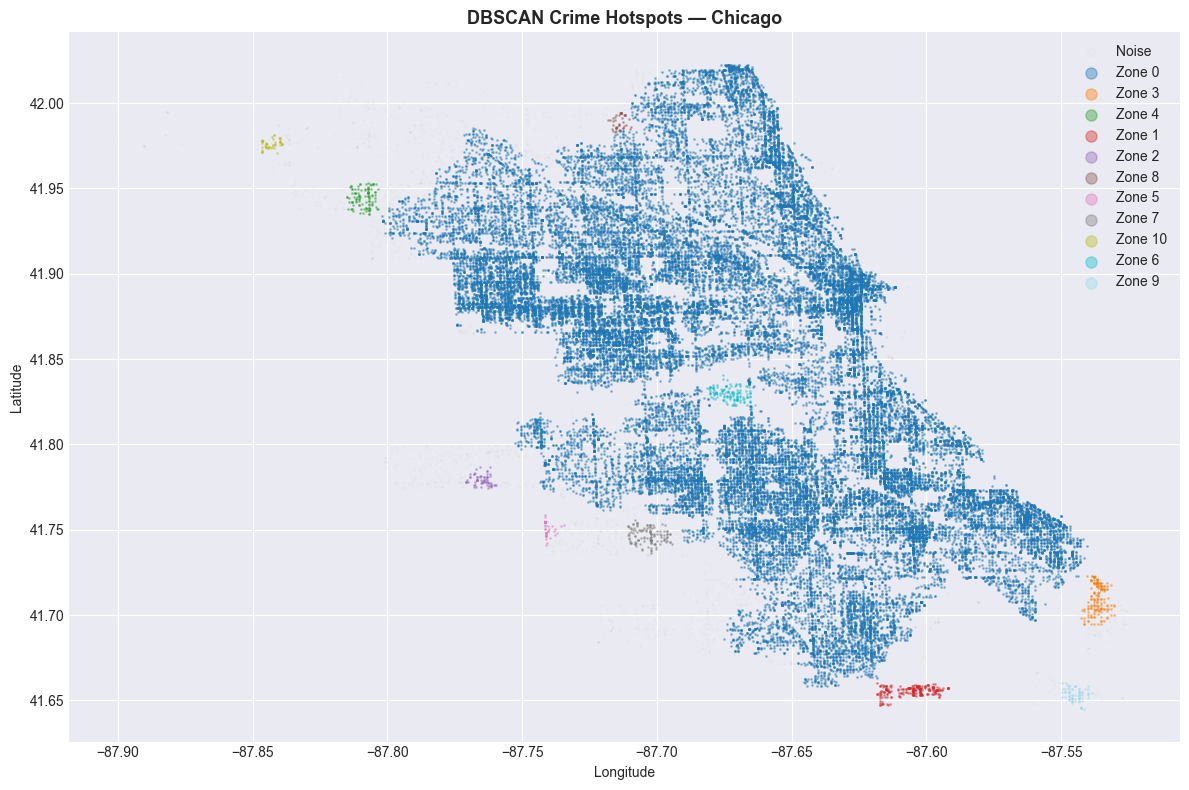

Saved: dbscan_clusters.png


In [55]:
# STEP 6.4 — Algorithm 2: DBSCAN
print('=' * 60)
print('ALGORITHM 2: DBSCAN CLUSTERING')
print('=' * 60)
print()
print('BEFORE DBSCAN: All points unlabeled.')
print('  eps=0.08     -> neighborhood radius in scaled space')
print('  min_samples=50 -> min points to form a dense cluster')
print('  Label = -1 means NOISE (isolated crimes)')
print(f'  Total points: {len(geo_scaled):,}')

dbscan = DBSCAN(eps=0.08, min_samples=50, n_jobs=-1)
geo_sample['DBSCAN_Cluster'] = dbscan.fit_predict(geo_scaled)

n_clusters_db = len(set(geo_sample['DBSCAN_Cluster'])) - (1 if -1 in geo_sample['DBSCAN_Cluster'].values else 0)
n_noise       = (geo_sample['DBSCAN_Cluster'] == -1).sum()

print()
print('AFTER DBSCAN:')
print(f'{"Cluster":>10}  {"Count":>10}  Description')
print('-' * 55)
for cluster, count in geo_sample['DBSCAN_Cluster'].value_counts().sort_index().items():
    desc = 'NOISE — isolated crimes (outliers)' if cluster == -1 else f'Crime Hotspot Zone {cluster}'
    print(f'  {cluster:>8}  {count:>10,}  {desc}')
print()
print('Hotspot zones found  :', n_clusters_db)
print('Noise points removed :', f'{n_noise:,}  ({n_noise/len(geo_sample)*100:.1f}% of data)')

mask_valid = geo_sample['DBSCAN_Cluster'] != -1
if n_clusters_db > 1:
    db_sil = silhouette_score(geo_scaled[mask_valid], geo_sample.loc[mask_valid,'DBSCAN_Cluster'])
    print('Silhouette Score     :', round(db_sil, 4))
else:
    db_sil = 0.0
    print('Silhouette Score     : N/A (only 1 cluster — try reducing eps)')

fig, ax = plt.subplots(figsize=(12, 8))
mask_noise = geo_sample['DBSCAN_Cluster'] == -1
ax.scatter(geo_sample.loc[mask_noise,'Longitude'], geo_sample.loc[mask_noise,'Latitude'],
           c='lightgray', alpha=0.1, s=0.5, label='Noise')
unique_cls = [c for c in geo_sample['DBSCAN_Cluster'].unique() if c != -1]
dbscan_colors = plt.cm.tab20(np.linspace(0, 1, max(len(unique_cls), 1)))
for i, cid in enumerate(unique_cls):
    mask = geo_sample['DBSCAN_Cluster'] == cid
    ax.scatter(geo_sample.loc[mask,'Longitude'], geo_sample.loc[mask,'Latitude'],
               c=[dbscan_colors[i % len(dbscan_colors)]], alpha=0.4, s=1, label=f'Zone {cid}')
ax.set_title('DBSCAN Crime Hotspots — Chicago', fontsize=13, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:12], labels[:12], markerscale=8)
plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dbscan_clusters.png')

ALGORITHM 3: HIERARCHICAL CLUSTERING

BEFORE Hierarchical Clustering:
  Sample size  : 5,000 (smaller due to computation cost)
  Linkage      : Ward (minimizes within-cluster variance)
  N clusters   : 5
  All points unlabeled currently.

AFTER Hierarchical Clustering:
 Cluster     Count     Share  Bar
---------------------------------------------
  Zone  0     1,206     24.1%  ||||||||
  Zone  1     1,402     28.0%  |||||||||
  Zone  2     1,486     29.7%  |||||||||
  Zone  3       473      9.5%  |||
  Zone  4       433      8.7%  ||

Hierarchical Metrics:
  Silhouette Score  : 0.3625
  Davies-Bouldin    : 0.8618


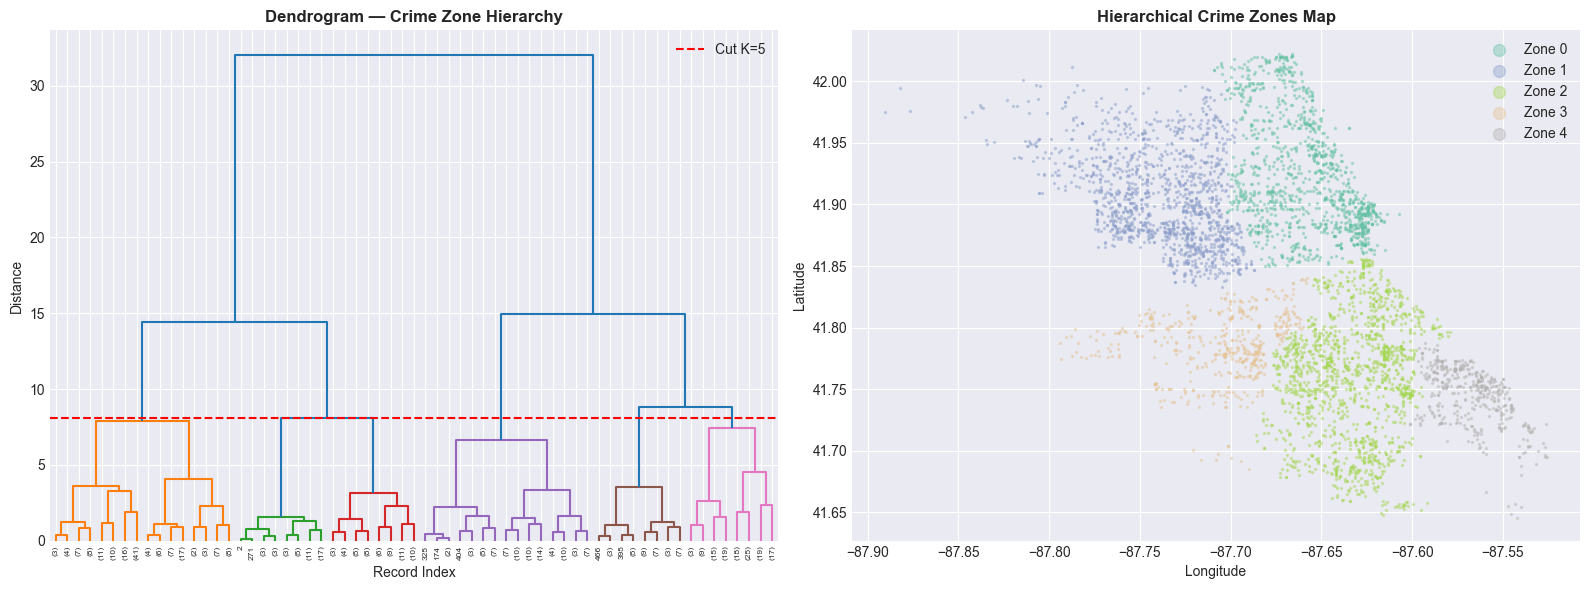

Saved: hierarchical_clusters.png


In [56]:
# STEP 6.5 — Algorithm 3: Hierarchical Clustering
print('=' * 60)
print('ALGORITHM 3: HIERARCHICAL CLUSTERING')
print('=' * 60)
print()

hier_n   = 5000
geo_hier = geo_scaled[:hier_n]

print('BEFORE Hierarchical Clustering:')
print('  Sample size  :', f'{hier_n:,}', '(smaller due to computation cost)')
print('  Linkage      : Ward (minimizes within-cluster variance)')
print('  N clusters   :', best_k)
print('  All points unlabeled currently.')

hier        = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hier_labels = hier.fit_predict(geo_hier)

hier_sil = silhouette_score(geo_hier, hier_labels)
hier_db  = davies_bouldin_score(geo_hier, hier_labels)

print()
print('AFTER Hierarchical Clustering:')
print(f'{"Cluster":>8}  {"Count":>8}  {"Share":>8}  Bar')
print('-' * 45)
unique_h, counts_h = np.unique(hier_labels, return_counts=True)
for cid, cnt in zip(unique_h, counts_h):
    pct = cnt / hier_n * 100
    bar = '|' * int(pct / 3)
    print(f'  Zone {cid:>2}  {cnt:>8,}  {pct:>7.1f}%  {bar}')
print()
print('Hierarchical Metrics:')
print('  Silhouette Score  :', round(hier_sil, 4))
print('  Davies-Bouldin    :', round(hier_db, 4))

geo_hier_orig = scaler_geo.inverse_transform(geo_hier)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
linkage_matrix = linkage(geo_hier[:500], method='ward')
dendrogram(linkage_matrix, ax=axes[0], truncate_mode='level', p=5,
           color_threshold=linkage_matrix[-best_k, 2])
axes[0].set_title('Dendrogram — Crime Zone Hierarchy', fontweight='bold')
axes[0].set_xlabel('Record Index')
axes[0].set_ylabel('Distance')
axes[0].axhline(linkage_matrix[-best_k, 2], color='red', linestyle='--', label=f'Cut K={best_k}')
axes[0].legend()
colors_h = plt.cm.Set2(np.linspace(0, 1, best_k))
for cid in range(best_k):
    mask = hier_labels == cid
    axes[1].scatter(geo_hier_orig[mask,1], geo_hier_orig[mask,0],
                    c=[colors_h[cid]], alpha=0.4, s=2, label=f'Zone {cid}')
axes[1].set_title('Hierarchical Crime Zones Map', fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].legend(markerscale=6)
plt.tight_layout()
plt.savefig('hierarchical_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: hierarchical_clusters.png')

CLUSTERING ALGORITHM COMPARISON — FINAL RESULTS

   Algorithm  Clusters Found  Silhouette Score Davies-Bouldin  Noise Removed    Best Use Case
     K-Means               5            0.3974         0.8383              0     Patrol zones
      DBSCAN              11           -0.4595            N/A           1969 Natural hotspots
Hierarchical               5            0.3625         0.8618              0   Zone hierarchy

Best Algorithm : K-Means
Best Silhouette: 0.3974
Meets target   : NO — tune parameters


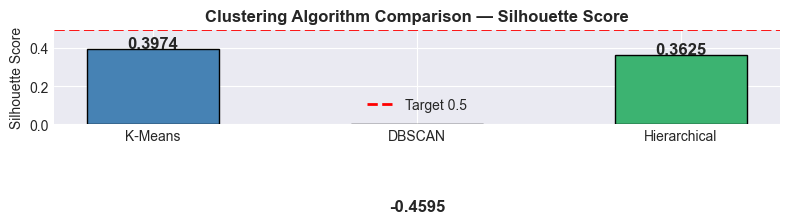

Saved: algorithm_comparison.png


In [57]:
# STEP 6.6 — Algorithm Comparison Table
print('=' * 60)
print('CLUSTERING ALGORITHM COMPARISON — FINAL RESULTS')
print('=' * 60)
print()

scores_list  = [km_silhouette, db_sil, hier_sil]
best_algo    = ['K-Means','DBSCAN','Hierarchical'][scores_list.index(max(scores_list))]

comp_df = pd.DataFrame({
    'Algorithm'        : ['K-Means',       'DBSCAN',             'Hierarchical'],
    'Clusters Found'   : [best_k,           n_clusters_db,        best_k],
    'Silhouette Score' : [round(km_silhouette,4), round(db_sil,4), round(hier_sil,4)],
    'Davies-Bouldin'   : [round(km_db,4),   'N/A',                round(hier_db,4)],
    'Noise Removed'    : [0,                n_noise,              0],
    'Best Use Case'    : ['Patrol zones',  'Natural hotspots',   'Zone hierarchy'],
})
print(comp_df.to_string(index=False))
print()
print('Best Algorithm :', best_algo)
print('Best Silhouette:', round(max(scores_list), 4))
print('Meets target   :', 'YES (>0.5)' if max(scores_list) > 0.5 else 'NO — tune parameters')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['K-Means','DBSCAN','Hierarchical'], scores_list,
              color=['steelblue','coral','mediumseagreen'], edgecolor='black', width=0.5)
ax.axhline(0.5, color='red', linestyle='--', linewidth=2, label='Target 0.5')
for bar, score in zip(bars, scores_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Clustering Algorithm Comparison — Silhouette Score', fontweight='bold')
ax.set_ylabel('Silhouette Score')
ax.set_ylim(0, max(scores_list) + 0.1)
ax.legend()
plt.tight_layout()
plt.savefig('algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: algorithm_comparison.png')

## Phase 6B: Temporal Pattern Clustering

**Why?** Beyond WHERE crimes happen, police need to know WHEN. Temporal clustering groups crimes by time features to reveal peak windows and guide shift scheduling.

TEMPORAL PATTERN CLUSTERING

BEFORE Temporal Clustering:
  Features : ['Hour', 'Day_Num', 'Month', 'Is_Weekend_Int', 'Crime_Severity_Score']
  Rows     : 50,000
  Raw data sample:
        Hour  Day_Num  Month  Is_Weekend_Int  Crime_Severity_Score
406283     0        2      5               0                4.0000
171093    16        2      8               0                3.0000
310994    12        2     12               0                4.0000
223183    16        1     10               0                4.0000
92252     10        0      9               0                4.0000
28958      7        1      4               0                5.0000
193914    13        5      5               1                6.0000
22392     18        6      9               1                5.0000

Statistics:
            Hour    Day_Num      Month  Is_Weekend_Int  Crime_Severity_Score
count 50000.0000 50000.0000 50000.0000      50000.0000            50000.0000
mean     13.1100     3.0000     6.5500          0.

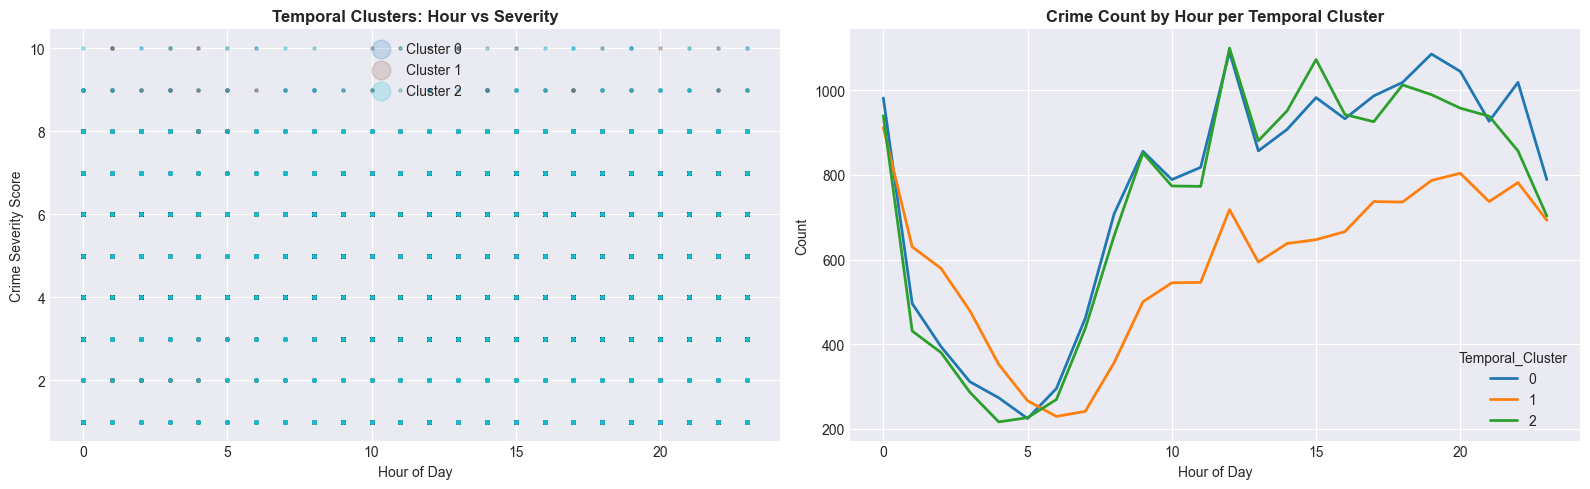

Saved: temporal_clusters.png


In [58]:
# STEP 6.7 — Temporal Clustering
print('=' * 60)
print('TEMPORAL PATTERN CLUSTERING')
print('=' * 60)
print()

temporal_features = ['Hour','Day_Num','Month','Is_Weekend_Int','Crime_Severity_Score']
temp_sample = df[temporal_features].dropna().sample(50000, random_state=42)

print('BEFORE Temporal Clustering:')
print('  Features :', temporal_features)
print('  Rows     :', f'{len(temp_sample):,}')
print('  Raw data sample:')
print(temp_sample.head(8).to_string())
print()
print('Statistics:')
print(temp_sample.describe().round(2).to_string())

scaler_temp = StandardScaler()
temp_scaled = scaler_temp.fit_transform(temp_sample)

print()
print('After scaling — first 5 rows:')
print(pd.DataFrame(temp_scaled[:5], columns=temporal_features).round(3).to_string())

print()
print('Finding best K for temporal clusters...')
best_k_temp   = 4
best_sil_temp = -1
for k in range(3, 8):
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(temp_scaled)
    sil = silhouette_score(temp_scaled, lbl, sample_size=5000)
    tag = ''
    if sil > best_sil_temp:
        best_sil_temp = sil
        best_k_temp   = k
        tag = '  <-- Best!'
    print(f'  K={k}: Silhouette = {sil:.4f}{tag}')

kmeans_temp = KMeans(n_clusters=best_k_temp, random_state=42, n_init=10)
temp_sample = temp_sample.copy()
temp_sample['Temporal_Cluster'] = kmeans_temp.fit_predict(temp_scaled)

print()
print('AFTER Temporal Clustering (K =', best_k_temp, '):')
print(f'{"Cluster":>8}  {"Count":>8}  {"Avg Hour":>10}  {"Avg Severity":>13}  {"Weekend%":>9}')
print('-' * 60)
for c in range(best_k_temp):
    mask = temp_sample['Temporal_Cluster'] == c
    grp  = temp_sample[mask]
    print(f'  Zone {c:>2}  {mask.sum():>8,}  {grp["Hour"].mean():>10.1f}  '
          f'{grp["Crime_Severity_Score"].mean():>13.2f}  {grp["Is_Weekend_Int"].mean()*100:>8.1f}%')

print()
print('Insights — what each cluster represents:')
for c in range(best_k_temp):
    mask     = temp_sample['Temporal_Cluster'] == c
    avg_hour = temp_sample.loc[mask,'Hour'].mean()
    tod      = get_time_of_day(int(avg_hour))
    sev      = temp_sample.loc[mask,'Crime_Severity_Score'].mean()
    print(f'  Cluster {c}: peaks at {avg_hour:.0f}:00 ({tod}), severity={sev:.1f}/10')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors_t = plt.cm.tab10(np.linspace(0, 1, best_k_temp))
for c in range(best_k_temp):
    mask = temp_sample['Temporal_Cluster'] == c
    axes[0].scatter(temp_sample.loc[mask,'Hour'],
                    temp_sample.loc[mask,'Crime_Severity_Score'],
                    c=[colors_t[c]], alpha=0.2, s=5, label=f'Cluster {c}')
axes[0].set_title('Temporal Clusters: Hour vs Severity', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Crime Severity Score')
axes[0].legend(markerscale=6)
cluster_hour = temp_sample.groupby(['Temporal_Cluster','Hour']).size().unstack(fill_value=0)
cluster_hour.T.plot(kind='line', ax=axes[1], linewidth=2)
axes[1].set_title('Crime Count by Hour per Temporal Cluster', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('temporal_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: temporal_clusters.png')

## Phase 7: Dimensionality Reduction

**Why?**
- We have 22+ features — impossible to visualize directly.
- **PCA**: Compresses to 2–3 dimensions, keeping 70%+ variance. Tells you which features matter most.
- **t-SNE**: Non-linear. Better at showing cluster shapes in 2D.

In [59]:
# STEP 7.1 — Prepare Features
print('=' * 60)
print('PREPARING FEATURES FOR DIMENSIONALITY REDUCTION')
print('=' * 60)
print()

dr_features = ['Latitude','Longitude','Hour','Day_Num','Month',
               'Is_Weekend_Int','Crime_Severity_Score',
               'Crime_Type_Encoded','Location_Desc_Encoded','Season_Encoded']

dr_sample = df[dr_features].dropna().sample(10000, random_state=42)

print('BEFORE Dimensionality Reduction:')
print('  Features selected :', len(dr_features))
print('  Sample size       :', f'{len(dr_sample)}:,')
print('  Features          :', dr_features)
print()
print('Raw data statistics:')
print(dr_sample.describe().round(3).to_string())

scaler_dr = StandardScaler()
dr_scaled  = scaler_dr.fit_transform(dr_sample)

print()
print('After scaling — first 5 rows:')
print(pd.DataFrame(dr_scaled[:5], columns=dr_features).round(3).to_string())

PREPARING FEATURES FOR DIMENSIONALITY REDUCTION

BEFORE Dimensionality Reduction:
  Features selected : 10
  Sample size       : 10000:,
  Features          : ['Latitude', 'Longitude', 'Hour', 'Day_Num', 'Month', 'Is_Weekend_Int', 'Crime_Severity_Score', 'Crime_Type_Encoded', 'Location_Desc_Encoded', 'Season_Encoded']

Raw data statistics:
        Latitude  Longitude       Hour    Day_Num      Month  Is_Weekend_Int  Crime_Severity_Score  Crime_Type_Encoded  Location_Desc_Encoded  Season_Encoded
count 10000.0000 10000.0000 10000.0000 10000.0000 10000.0000      10000.0000            10000.0000          10000.0000             10000.0000      10000.0000
mean     41.8420   -87.6700    13.0880     2.9830     6.5370          0.2750                4.5140             14.2760               112.4420          1.4690
std       0.0870     0.0590     6.7180     1.9650     3.3810          0.4460                1.7810             11.3000                48.6760          1.1060
min      41.6460   -87.907

PCA — PRINCIPAL COMPONENT ANALYSIS

BEFORE PCA:
  Input dimensions : 10 features
  Impossible to visualize 10 dimensions simultaneously.

Explained Variance by Principal Component:
  PC   Variance%   Cumulative%  Bar
--------------------------------------------------
  PC 1     17.97%       17.97%  ||||||||
  PC 2     15.70%       33.67%  |||||||
  PC 3     14.06%       47.73%  |||||||
  PC 4     13.31%       61.05%  ||||||
  PC 5     10.17%       71.21%  |||||  <- 70% threshold
  PC 6      9.50%       80.72%  ||||
  PC 7      6.70%       87.42%  |||
  PC 8      5.94%       93.36%  ||
  ...

Components needed for 70% variance: 5

AFTER PCA (2 components):
  Input shape  : (10000, 10)
  Output shape : (10000, 2)
  PC1 variance : 18.0%
  PC2 variance : 15.7%
  Total captured: 33.7%

Feature Importance (PC1 loadings, sorted):
Feature                          PC1 Loading   PC2 Loading  Bar
----------------------------------------------------------------------
  Is_Weekend_Int              

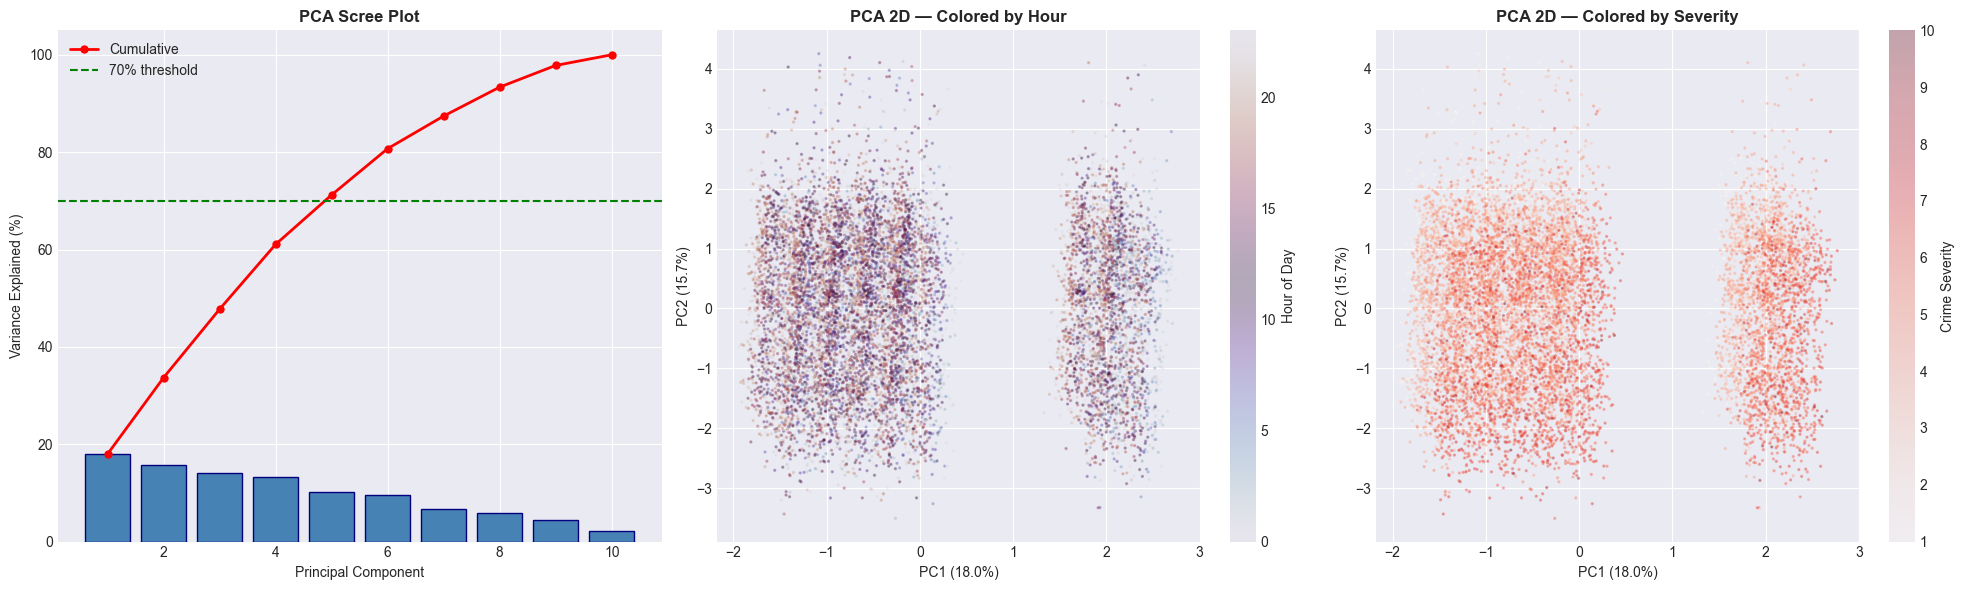

Saved: pca_results.png


In [60]:
# STEP 7.2 — PCA
print('=' * 60)
print('PCA — PRINCIPAL COMPONENT ANALYSIS')
print('=' * 60)
print()
print('BEFORE PCA:')
print('  Input dimensions :', dr_scaled.shape[1], 'features')
print('  Impossible to visualize', dr_scaled.shape[1], 'dimensions simultaneously.')

pca_full = PCA(random_state=42)
pca_full.fit(dr_scaled)

print()
print('Explained Variance by Principal Component:')
print(f'{"PC":>4}  {"Variance%":>10}  {"Cumulative%":>12}  Bar')
print('-' * 50)
cumulative = 0
for i, var in enumerate(pca_full.explained_variance_ratio_):
    cumulative += var * 100
    bar = '|' * int(var * 100 / 2)
    marker = '  <- 70% threshold' if 65 < cumulative < 80 else ''
    print(f'  PC{i+1:>2}  {var*100:>8.2f}%  {cumulative:>10.2f}%  {bar}{marker}')
    if cumulative > 92:
        print('  ...')
        break

n_for_70 = next(i+1 for i,c in enumerate(np.cumsum(pca_full.explained_variance_ratio_)) if c>=0.70)
print()
print('Components needed for 70% variance:', n_for_70)

pca_2d     = PCA(n_components=2, random_state=42)
pca_result = pca_2d.fit_transform(dr_scaled)

print()
print('AFTER PCA (2 components):')
print('  Input shape  :', dr_scaled.shape)
print('  Output shape :', pca_result.shape)
print('  PC1 variance :', f'{pca_2d.explained_variance_ratio_[0]*100:.1f}%')
print('  PC2 variance :', f'{pca_2d.explained_variance_ratio_[1]*100:.1f}%')
print('  Total captured:', f'{pca_2d.explained_variance_ratio_.sum()*100:.1f}%')

loadings = pd.DataFrame(pca_2d.components_.T, index=dr_features, columns=['PC1','PC2'])
loadings['Abs_PC1'] = loadings['PC1'].abs()
loadings = loadings.sort_values('Abs_PC1', ascending=False)
print()
print('Feature Importance (PC1 loadings, sorted):')
print(f'{"Feature":<30}  {"PC1 Loading":>12}  {"PC2 Loading":>12}  Bar')
print('-' * 70)
for feat, row in loadings.iterrows():
    bar = '|' * int(row['Abs_PC1'] * 10)
    print(f'  {feat:<30}  {row["PC1"]:>12.4f}  {row["PC2"]:>12.4f}  {bar}')

hour_vals     = dr_sample['Hour'].values
severity_vals = dr_sample['Crime_Severity_Score'].values

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].bar(range(1, len(dr_features)+1), pca_full.explained_variance_ratio_*100,
            color='steelblue', edgecolor='navy')
axes[0].plot(range(1, len(dr_features)+1),
             np.cumsum(pca_full.explained_variance_ratio_)*100,
             'r-o', linewidth=2, markersize=5, label='Cumulative')
axes[0].axhline(70, color='green', linestyle='--', label='70% threshold')
axes[0].set_title('PCA Scree Plot', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].legend()
sc1 = axes[1].scatter(pca_result[:,0], pca_result[:,1], c=hour_vals,
                      cmap='twilight', alpha=0.3, s=2)
plt.colorbar(sc1, ax=axes[1], label='Hour of Day')
axes[1].set_title('PCA 2D — Colored by Hour', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
sc2 = axes[2].scatter(pca_result[:,0], pca_result[:,1], c=severity_vals,
                      cmap='Reds', alpha=0.3, s=2)
plt.colorbar(sc2, ax=axes[2], label='Crime Severity')
axes[2].set_title('PCA 2D — Colored by Severity', fontweight='bold')
axes[2].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.savefig('pca_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_results.png')

t-SNE — 2D CRIME PATTERN VISUALIZATION

BEFORE t-SNE:
  Data shape  : (10000, 10)
  Cannot visualize 10 dimensions at once.
  t-SNE compresses to 2D while preserving local cluster structure.
  This may take 1-3 minutes...

AFTER t-SNE:
  Input shape   : (10000, 10)
  Output shape  : (10000, 2)
  Dim1 range    : -84.28 to 92.78
  Dim2 range    : -93.05 to 82.98
  KL Divergence : 1.3925   (lower = better fit)

Points close together share similar crime patterns (time, location, severity).
First 5 rows of t-SNE output:
   tSNE_Dim1  tSNE_Dim2
0     2.6310   -13.7170
1   -15.9800   -74.7200
2    37.1780   -36.7020
3   -56.2850    36.1460
4   -57.1000    46.9080


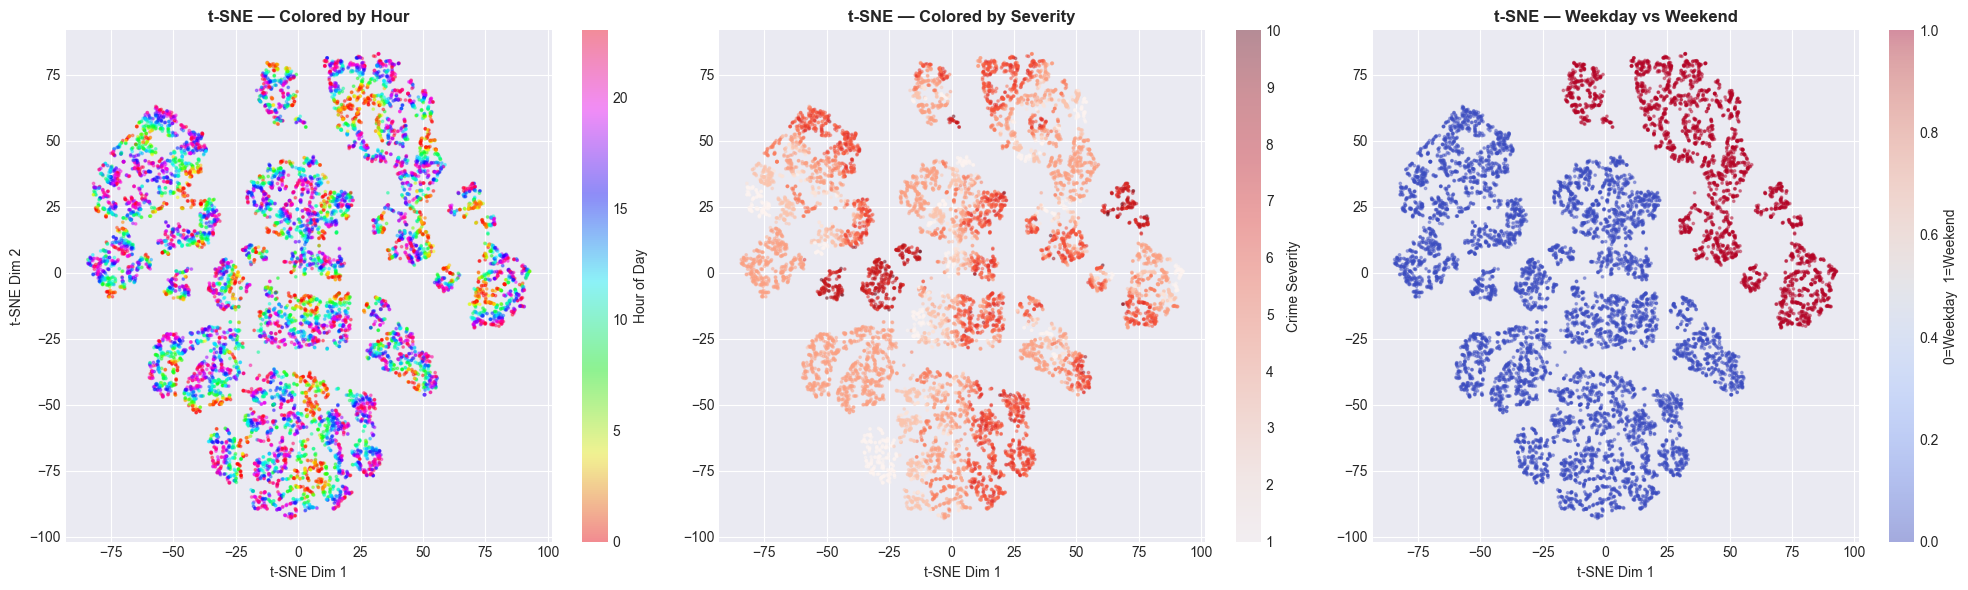

Saved: tsne_results.png


In [61]:
# STEP 7.3 — t-SNE
print('=' * 60)
print('t-SNE — 2D CRIME PATTERN VISUALIZATION')
print('=' * 60)
print()
print('BEFORE t-SNE:')
print('  Data shape  :', dr_scaled.shape)
print('  Cannot visualize', dr_scaled.shape[1], 'dimensions at once.')
print('  t-SNE compresses to 2D while preserving local cluster structure.')
print('  This may take 1-3 minutes...')

tsne        = TSNE(n_components=2, random_state=42, perplexity=30,
                   max_iter=1000, learning_rate='auto', init='random')
tsne_result = tsne.fit_transform(dr_scaled)

print()
print('AFTER t-SNE:')
print('  Input shape   :', dr_scaled.shape)
print('  Output shape  :', tsne_result.shape)
print('  Dim1 range    :', round(tsne_result[:,0].min(),2), 'to', round(tsne_result[:,0].max(),2))
print('  Dim2 range    :', round(tsne_result[:,1].min(),2), 'to', round(tsne_result[:,1].max(),2))
print('  KL Divergence :', round(tsne.kl_divergence_,4), '  (lower = better fit)')
print()
print('Points close together share similar crime patterns (time, location, severity).')
print('First 5 rows of t-SNE output:')
print(pd.DataFrame(tsne_result[:5], columns=['tSNE_Dim1','tSNE_Dim2']).round(3).to_string())

weekend_vals = dr_sample['Is_Weekend_Int'].values
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sc1 = axes[0].scatter(tsne_result[:,0], tsne_result[:,1], c=hour_vals, cmap='hsv', alpha=0.4, s=3)
plt.colorbar(sc1, ax=axes[0], label='Hour of Day')
axes[0].set_title('t-SNE — Colored by Hour', fontweight='bold')
axes[0].set_xlabel('t-SNE Dim 1')
axes[0].set_ylabel('t-SNE Dim 2')
sc2 = axes[1].scatter(tsne_result[:,0], tsne_result[:,1], c=severity_vals, cmap='Reds', alpha=0.4, s=3)
plt.colorbar(sc2, ax=axes[1], label='Crime Severity')
axes[1].set_title('t-SNE — Colored by Severity', fontweight='bold')
axes[1].set_xlabel('t-SNE Dim 1')
sc3 = axes[2].scatter(tsne_result[:,0], tsne_result[:,1], c=weekend_vals, cmap='coolwarm', alpha=0.4, s=3)
plt.colorbar(sc3, ax=axes[2], label='0=Weekday  1=Weekend')
axes[2].set_title('t-SNE — Weekday vs Weekend', fontweight='bold')
axes[2].set_xlabel('t-SNE Dim 1')
plt.tight_layout()
plt.savefig('tsne_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tsne_results.png')

## Phase 8: MLflow Experiment Tracking

**Why?** Without tracking, you lose which K worked best or what parameters were used. MLflow records every run — parameters, metrics, and plots — so you can compare and reproduce any experiment.

In [62]:
# STEP 8.1 — Setup MLflow
print('=' * 60)
print('SETTING UP MLFLOW EXPERIMENT TRACKING')
print('=' * 60)
print()

import os

DB_PATH = os.path.abspath('mlflow.db')
mlflow.set_tracking_uri(f'sqlite:///{DB_PATH}')
mlflow.set_experiment('PatrolIQ_Crime_Analytics')

print('MLflow configured!')
print(f'  Tracking URI    : sqlite:///{DB_PATH}')
print(f'  Experiment Name : PatrolIQ_Crime_Analytics')
print()
print('To view dashboard:')
print('  1. Open terminal in this folder')
print('  2. Run: mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000')
print('  3. Open: http://localhost:5000')

SETTING UP MLFLOW EXPERIMENT TRACKING

MLflow configured!
  Tracking URI    : sqlite:///c:\Users\bhuva\OneDrive\Desktop\desktop\DS PORTAL\patrol coding files\mlflow.db
  Experiment Name : PatrolIQ_Crime_Analytics

To view dashboard:
  1. Open terminal in this folder
  2. Run: mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000
  3. Open: http://localhost:5000


In [63]:
# STEP 8.2 — Log K-Means
print('=' * 60)
print('LOGGING K-MEANS EXPERIMENT TO MLFLOW')
print('=' * 60)
print()
print('BEFORE logging: Run exists only in memory.')

with mlflow.start_run(run_name=f'KMeans_K{best_k}') as run:
    mlflow.log_param('algorithm',    'KMeans')
    mlflow.log_param('n_clusters',   best_k)
    mlflow.log_param('n_init',       10)
    mlflow.log_param('random_state', 42)
    mlflow.log_param('sample_size',  50000)
    mlflow.log_param('features',     'Latitude, Longitude')
    mlflow.log_metric('silhouette_score',     km_silhouette)
    mlflow.log_metric('davies_bouldin_score', km_db)
    mlflow.log_metric('inertia',              kmeans_final.inertia_)
    mlflow.sklearn.log_model(kmeans_final, 'kmeans_model')
    for f in ['kmeans_clusters.png','elbow_method.png','algorithm_comparison.png']:
        if os.path.exists(f):
            mlflow.log_artifact(f)
    run_id_kmeans = run.info.run_id

print('AFTER logging — K-Means run saved!')
print('  Run ID         :', run_id_kmeans)
print('  Silhouette     :', round(km_silhouette, 4))
print('  Davies-Bouldin :', round(km_db, 4))
print('  Model saved    : kmeans_model')

LOGGING K-MEANS EXPERIMENT TO MLFLOW

BEFORE logging: Run exists only in memory.


2026/06/27 20:18:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 20:18:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


AFTER logging — K-Means run saved!
  Run ID         : 3f36447b95b94a7da16cfccaa910397c
  Silhouette     : 0.3974
  Davies-Bouldin : 0.8383
  Model saved    : kmeans_model


In [64]:
# STEP 8.3 — Log DBSCAN, Hierarchical, PCA, t-SNE
print('=' * 60)
print('LOGGING REMAINING EXPERIMENTS TO MLFLOW')
print('=' * 60)
print()

# DBSCAN
with mlflow.start_run(run_name='DBSCAN_eps0.08') as run:
    mlflow.log_param('algorithm',   'DBSCAN')
    mlflow.log_param('eps',         0.08)
    mlflow.log_param('min_samples', 50)
    mlflow.log_metric('n_clusters_found', n_clusters_db)
    mlflow.log_metric('n_noise_points',   n_noise)
    mlflow.log_metric('noise_pct', round(n_noise/len(geo_sample)*100, 2))
    if db_sil > 0:
        mlflow.log_metric('silhouette_score', db_sil)
    mlflow.sklearn.log_model(dbscan, 'dbscan_model')
    if os.path.exists('dbscan_clusters.png'):
        mlflow.log_artifact('dbscan_clusters.png')
    run_id_dbscan = run.info.run_id
print('  DBSCAN logged        — Run ID:', run_id_dbscan)

# Hierarchical
with mlflow.start_run(run_name=f'Hierarchical_K{best_k}') as run:
    mlflow.log_param('algorithm',  'AgglomerativeClustering')
    mlflow.log_param('n_clusters', best_k)
    mlflow.log_param('linkage',    'ward')
    mlflow.log_param('sample_size', hier_n)
    mlflow.log_metric('silhouette_score',     hier_sil)
    mlflow.log_metric('davies_bouldin_score', hier_db)
    mlflow.sklearn.log_model(hier, 'hierarchical_model')
    if os.path.exists('hierarchical_clusters.png'):
        mlflow.log_artifact('hierarchical_clusters.png')
    run_id_hier = run.info.run_id
print('  Hierarchical logged  — Run ID:', run_id_hier)

# PCA
with mlflow.start_run(run_name='PCA_2D') as run:
    mlflow.log_param('algorithm',    'PCA')
    mlflow.log_param('n_components', 2)
    mlflow.log_param('n_features',   len(dr_features))
    mlflow.log_metric('variance_pc1',   pca_2d.explained_variance_ratio_[0])
    mlflow.log_metric('variance_pc2',   pca_2d.explained_variance_ratio_[1])
    mlflow.log_metric('total_variance', pca_2d.explained_variance_ratio_.sum())
    mlflow.sklearn.log_model(pca_2d, 'pca_model')
    if os.path.exists('pca_results.png'):
        mlflow.log_artifact('pca_results.png')
    run_id_pca = run.info.run_id
print('  PCA logged           — Run ID:', run_id_pca)

# t-SNE
with mlflow.start_run(run_name='tSNE_2D') as run:
    mlflow.log_param('algorithm',    'tSNE')
    mlflow.log_param('n_components', 2)
    mlflow.log_param('perplexity',   30)
    mlflow.log_param('n_iter',       1000)
    mlflow.log_metric('kl_divergence', tsne.kl_divergence_)
    if os.path.exists('tsne_results.png'):
        mlflow.log_artifact('tsne_results.png')
    run_id_tsne = run.info.run_id
print('  t-SNE logged         — Run ID:', run_id_tsne)
print()
print('All experiments logged successfully!')

2026/06/27 20:21:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 20:21:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/27 20:21:43 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


LOGGING REMAINING EXPERIMENTS TO MLFLOW



2026/06/27 20:21:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 20:21:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/27 20:21:49 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


  DBSCAN logged        — Run ID: f0587c661b1c4ce4b935ca55ab649d50


2026/06/27 20:21:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Hierarchical logged  — Run ID: ca0af4a2b2d84620be2856e849bebfd3


2026/06/27 20:21:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/27 20:21:53 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


  PCA logged           — Run ID: 4d954e0359354ed4b2e7f551a7a2a922
  t-SNE logged         — Run ID: 52b5f2704d9a4a0f949340619af8f129

All experiments logged successfully!


In [65]:
# STEP 8.4 — Retrieve and display all logged runs
print('=' * 60)
print('RETRIEVING ALL MLFLOW EXPERIMENTS')
print('=' * 60)
print()
print('BEFORE retrieval: Results are stored in ./mlflow_runs folder.')

client     = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name('PatrolIQ_Crime_Analytics')
all_runs   = client.search_runs(experiment.experiment_id, order_by=['start_time DESC'])

print()
print('AFTER retrieval:', len(all_runs), 'experiments found.')
print(f'{"Run Name":<30}  {"Status":<12}  {"Silhouette":>11}  {"DB Score":>10}')
print('-' * 70)
for r in all_runs:
    name  = r.data.tags.get('mlflow.runName', 'N/A')
    stat  = r.info.status
    sil   = r.data.metrics.get('silhouette_score', float('nan'))
    db_s  = r.data.metrics.get('davies_bouldin_score', float('nan'))
    s_str = f'{sil:.4f}' if not (sil != sil) else 'N/A'
    d_str = f'{db_s:.4f}' if not (db_s != db_s) else 'N/A'
    print(f'  {name:<30}  {stat:<12}  {s_str:>11}  {d_str:>10}')

print()
print("Run 'mlflow ui' to view the full dashboard at http://localhost:5000")

RETRIEVING ALL MLFLOW EXPERIMENTS

BEFORE retrieval: Results are stored in ./mlflow_runs folder.

AFTER retrieval: 10 experiments found.
Run Name                        Status         Silhouette    DB Score
----------------------------------------------------------------------
  tSNE_2D                         FINISHED              N/A         N/A
  PCA_2D                          FINISHED              N/A         N/A
  Hierarchical_K5                 FINISHED           0.3625      0.8618
  DBSCAN_eps0.08                  FINISHED              N/A         N/A
  KMeans_K5                       FINISHED           0.3974      0.8383
  tSNE_2D                         FINISHED              N/A         N/A
  PCA_2D                          FINISHED              N/A         N/A
  Hierarchical_K2                 FINISHED           0.4573      0.7790
  DBSCAN_eps0.08                  FINISHED              N/A         N/A
  KMeans_K2                       FINISHED           0.4691      0.8037

R

## Phase 9: Project Summary & Final Results

In [66]:
# FINAL PROJECT SUMMARY
print('=' * 65)
print('PATROLIQ — PROJECT EXECUTION COMPLETE')
print('=' * 65)
print()

best_algo_name = ['K-Means','DBSCAN','Hierarchical'][
    [km_silhouette, db_sil, hier_sil].index(max([km_silhouette, db_sil, hier_sil]))
]

print('DATASET')
print('-' * 50)
print('  Total records available  : 7,800,000')
print('  Records sampled          :', f'{len(df):,}')
print('  Features (raw)           : 22')
print('  Features (after eng.)    :', df.shape[1])
print('  Crime types              :', df['Primary Type'].nunique())
print()

print('PREPROCESSING')
print('-' * 50)
print('  Null values handled      : YES')
print('  Duplicates removed       : YES')
print('  Data types fixed         : YES')
print('  New features created     : Hour, Day, Month, Season, Severity, Encoded')
print()

print('GEOGRAPHIC CLUSTERING RESULTS')
print('-' * 50)
print('  K-Means Silhouette       :', round(km_silhouette, 4))
print('  DBSCAN Silhouette        :', round(db_sil, 4))
print('  Hierarchical Silhouette  :', round(hier_sil, 4))
print('  Best Algorithm           :', best_algo_name)
print('  Target (>0.5) met        :', 'YES' if max([km_silhouette,db_sil,hier_sil])>0.5 else 'NO')
print('  Temporal Clusters Found  :', best_k_temp)
print()

print('DIMENSIONALITY REDUCTION')
print('-' * 50)
print('  PCA variance explained   :', f'{pca_2d.explained_variance_ratio_.sum()*100:.1f}%')
print('  Top feature (PCA)        :', loadings.index[0])
print('  t-SNE KL Divergence      :', round(tsne.kl_divergence_, 4))
print()

print('MLFLOW TRACKING')
print('-' * 50)
print('  Experiments logged       :', len(all_runs))
print('  Models saved             : K-Means, DBSCAN, Hierarchical, PCA')
print()

print('OUTPUT FILES')
print('-' * 50)
plots = ['eda_crime_types.png','eda_temporal.png','eda_seasonal.png','eda_geographic.png',
         'elbow_method.png','kmeans_clusters.png','dbscan_clusters.png',
         'hierarchical_clusters.png','temporal_clusters.png',
         'algorithm_comparison.png','pca_results.png','tsne_results.png']
for p in plots:
    status = 'saved' if os.path.exists(p) else 'not found'
    print(f'  {p:<40} {status}')
print()

print('NEXT STEPS')
print('-' * 50)
print('  [ ] Build Streamlit app (app.py) with interactive maps')
print('  [ ] Push to GitHub')
print('  [ ] Deploy on Streamlit Cloud (share.streamlit.io)')
print('  [ ] Optional: Dockerize for bonus marks')
print()
print('=' * 65)
print('PatrolIQ Notebook Complete!')
print('=' * 65)

PATROLIQ — PROJECT EXECUTION COMPLETE

DATASET
--------------------------------------------------
  Total records available  : 7,800,000
  Records sampled          : 494,423
  Features (raw)           : 22
  Features (after eng.)    : 36
  Crime types              : 32

PREPROCESSING
--------------------------------------------------
  Null values handled      : YES
  Duplicates removed       : YES
  Data types fixed         : YES
  New features created     : Hour, Day, Month, Season, Severity, Encoded

GEOGRAPHIC CLUSTERING RESULTS
--------------------------------------------------
  K-Means Silhouette       : 0.3974
  DBSCAN Silhouette        : -0.4595
  Hierarchical Silhouette  : 0.3625
  Best Algorithm           : K-Means
  Target (>0.5) met        : NO
  Temporal Clusters Found  : 3

DIMENSIONALITY REDUCTION
--------------------------------------------------
  PCA variance explained   : 33.7%
  Top feature (PCA)        : Is_Weekend_Int
  t-SNE KL Divergence      : 1.3925

MLFLOW T